# From Traffic to Leads: Diagnosing the View-to-Contact Drop in Chợ Tốt Real Estate

**Datathon 2026 — Chợ Tốt Bất Động Sản**

---

## Executive Summary

Chợ Tốt Bất Động Sản (BĐS) là một trong những nền tảng rao vặt BĐS lớn nhất Việt Nam với hàng triệu tin đăng và hàng trăm triệu sự kiện người dùng mỗi kỳ. **Traffic không thiếu — nhưng hard lead (liên hệ thật) lại chưa tương xứng.**

Notebook này đi theo hướng phân tích từ **Descriptive → Diagnostic → Recommendation**:

1. **Descriptive Analysis** (ngắn gọn): Xác định điểm rơi chính trong funnel — từ **pageview → hard contact** là bước mất mát lớn nhất.
2. **Diagnostic Analysis** sử dụng framework **B = M × A × P** (Behavior = Motivation × Ability × Prompt) để tìm **nguyên nhân gốc rễ** khiến view không chuyển thành lead.
3. **Recommendations** đi trực tiếp từ từng root cause sang giải pháp cụ thể cho sản phẩm, vận hành và recommender system.

### Định nghĩa sự kiện
| Nhóm | Event types | Ý nghĩa |
|------|-------------|---------|
| **Hard contact** | `view_phone`, `contact_chat`, `contact_zalo`, `contact_sms` | Hành vi liên hệ trực tiếp — **đây là lead thật** |
| **Soft positive** | `other_interaction` | Tương tác tích cực nhưng chưa rõ ý định thương mại |
| **Pageview** | `pageview` | Xem chi tiết tin đăng |

> **Lưu ý**: Trường `purchased` trong dữ liệu là **purchase proxy** (nhãn dự đoán nội bộ), không phải giao dịch thật đã xác minh.

---
# 1. Setup & Configuration

In [45]:
import os
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pyarrow.parquet as pq
import pyarrow.dataset as ds
import pyarrow.compute as pc
import pyarrow as pa
from pathlib import Path
from datetime import datetime

warnings.filterwarnings('ignore')
np.random.seed(42)

# ── Paths ──
DATA_DIR = Path("data/processed")
DIM_PATH = DATA_DIR / "dim_listing_cleaned" / "dim_listing_cleaned.parquet"
SNAP_PATH = DATA_DIR / "fact_listing_snapshot_cleaned" / "fact_listing_snapshot_cleaned.parquet"
INTER_DIR = DATA_DIR / "fact_user_ad_interactions"
EVENTS_DIR = DATA_DIR / "clean_fact_user_events"

FIG_DIR = Path("outputs/figures")
TBL_DIR = Path("outputs/tables")
FIG_DIR.mkdir(parents=True, exist_ok=True)
TBL_DIR.mkdir(parents=True, exist_ok=True)

# ── Mode ──
MODE = "full_aggregate"  # "sample" or "full_aggregate"

# ── Date cutoff ──
TRAIN_END_DATE = "2026-04-09"

# ── Event definitions ──
POSITIVE_EVENTS = ["view_phone", "contact_chat", "other_interaction", "contact_zalo", "contact_sms"]
HARD_CONTACT_EVENTS = ["view_phone", "contact_chat", "contact_zalo", "contact_sms"]
SOFT_POSITIVE_EVENTS = ["other_interaction"]
PAGEVIEW_EVENT = "pageview"

# ── Category mapping ──
CATEGORY_MAP = {
    1010: "Phòng trọ/Studio",
    1020: "Căn hộ/Chung cư",
    1030: "Nhà ở",
    1040: "Đất",
    1050: "Dự án mở bán",
}

# ── Color palette (Storytelling with Data style - muted, purposeful) ──
C_PRIMARY   = "#2563EB"   # xanh dương đậm — focus chính
C_SECONDARY = "#64748B"   # xám — context
C_ACCENT    = "#EF4444"   # đỏ — highlight vấn đề
C_SUCCESS   = "#10B981"   # xanh lá — positive
C_WARNING   = "#F59E0B"   # vàng cam — cảnh báo
C_MUTED     = "#CBD5E1"   # xám nhạt — background bars
C_BG        = "#FFFFFF"
C_TEXT      = "#1E293B"

PALETTE_CAT = ["#2563EB", "#EF4444", "#10B981", "#F59E0B", "#8B5CF6"]

# ── Plot defaults (clean, Cole Nussbaumer style) ──
plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 11,
    'figure.dpi': 120,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
    'figure.facecolor': C_BG,
    'axes.facecolor': C_BG,
    'text.color': C_TEXT,
    'axes.labelcolor': C_TEXT,
    'xtick.color': '#64748B',
    'ytick.color': '#64748B',
    'axes.edgecolor': '#E2E8F0',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'grid.color': '#F1F5F9',
    'grid.alpha': 1.0,
})

print("✅ Setup hoàn tất")
print(f"   Mode: {MODE}")
print(f"   Data dir: {DATA_DIR}")
print(f"   Output: {FIG_DIR}, {TBL_DIR}")

✅ Setup hoàn tất
   Mode: full_aggregate
   Data dir: data\processed
   Output: outputs\figures, outputs\tables


---
# 2. Utility Functions

In [46]:
# ── Save & format helpers ──
def save_fig(filename, fig=None):
    """Save current figure to outputs/figures/"""
    if fig is None:
        fig = plt.gcf()
    fig.savefig(FIG_DIR / f"{filename}.png")
    plt.show()  # Display inline in notebook
    print(f"  💾 {filename}.png")

def safe_divide(num, den, fill=0.0):
    """Safe division avoiding ZeroDivisionError"""
    return num / den if den != 0 else fill

def format_percent(x, decimals=1):
    return f"{x:.{decimals}f}%"

def format_number(x):
    if abs(x) >= 1e6: return f"{x/1e6:.1f}M"
    if abs(x) >= 1e3: return f"{x/1e3:.1f}K"
    return f"{x:.0f}"

def contact_rate(contacts, views):
    """Calculate contact rate with safe division"""
    if isinstance(contacts, (pd.Series, np.ndarray)):
        return np.where(views > 0, contacts / views, 0.0)
    return safe_divide(contacts, views)

def map_category(df, col='category'):
    """Map category codes to Vietnamese names"""
    df = df.copy()
    df[col] = df[col].map(CATEGORY_MAP).fillna(df[col].astype(str))
    return df

In [47]:
# ── Data I/O helpers ──
def read_parquet_limited(path, columns=None, filters=None):
    """Read parquet with optional column/filter pruning"""
    try:
        table = pq.read_table(str(path), columns=columns, filters=filters)
        return table.to_pandas()
    except Exception as e:
        print(f"  ⚠️ Error reading {path}: {e}")
        return pd.DataFrame()

def aggregate_events_chunked(event_dir, group_cols, agg_col='event_type',
                              count_col='n_events', columns=None, 
                              filter_fn=None, max_files=None):
    """
    Loop through parquet files, read only needed columns, 
    aggregate per-file, then concat. Memory-safe for 24GB+ data.
    """
    files = sorted(Path(event_dir).glob("*.parquet"))
    if max_files and MODE == "sample":
        files = files[:max_files]
    
    results = []
    for i, f in enumerate(files):
        try:
            cols_to_read = list(set(group_cols + ([agg_col] if agg_col else []) + (columns or [])))
            chunk = pq.read_table(str(f), columns=cols_to_read).to_pandas()
            
            if filter_fn is not None:
                chunk = filter_fn(chunk)
            
            if len(chunk) == 0:
                continue
                
            agg = chunk.groupby(group_cols).size().reset_index(name=count_col)
            results.append(agg)
            
            if (i + 1) % 100 == 0:
                print(f"    Processed {i+1}/{len(files)} files...")
        except Exception as e:
            print(f"  ⚠️ Error on {f.name}: {e}")
            continue
    
    if not results:
        return pd.DataFrame()
    
    combined = pd.concat(results, ignore_index=True)
    final = combined.groupby(group_cols)[count_col].sum().reset_index()
    print(f"  ✅ Aggregated {len(files)} files → {len(final)} rows")
    return final

def sample_events_chunked(event_dir, columns, filter_fn=None,
                           sample_frac=0.01, max_files=None):
    """Sample rows from event files for distribution analysis"""
    files = sorted(Path(event_dir).glob("*.parquet"))
    if max_files and MODE == "sample":
        files = files[:max_files]
    
    results = []
    for f in files:
        try:
            chunk = pq.read_table(str(f), columns=columns).to_pandas()
            if filter_fn is not None:
                chunk = filter_fn(chunk)
            if len(chunk) > 0:
                results.append(chunk.sample(frac=sample_frac, random_state=42))
        except:
            continue
    
    if not results:
        return pd.DataFrame()
    return pd.concat(results, ignore_index=True)

In [48]:
# ── Plot helpers (Cole Nussbaumer style: minimal, focused) ──
def plot_bar_h(data, x_col, y_col, title, xlabel='', highlight_idx=None,
               color=C_MUTED, highlight_color=C_PRIMARY, figsize=(10, 6),
               show_values=True, value_fmt=None, filename=None):
    """Horizontal bar chart — SWD style with optional highlight"""
    fig, ax = plt.subplots(figsize=figsize)
    colors = [highlight_color if (highlight_idx and i in highlight_idx) else color
              for i in range(len(data))]
    bars = ax.barh(data[y_col], data[x_col], color=colors, edgecolor='none', height=0.6)
    
    if show_values:
        for bar in bars:
            w = bar.get_width()
            label = value_fmt(w) if value_fmt else format_number(w)
            ax.text(w * 1.02, bar.get_y() + bar.get_height()/2,
                    label, va='center', fontsize=10, color=C_TEXT)
    
    ax.set_title(title, fontweight='bold', loc='left', pad=15)
    ax.set_xlabel(xlabel)
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)
    ax.set_axisbelow(True)
    
    if filename:
        save_fig(filename, fig)
    return fig, ax

def plot_bar_v(data, x_col, y_col, title, ylabel='', colors=None,
               figsize=(10, 6), show_values=True, value_fmt=None,
               rotation=0, filename=None):
    """Vertical bar chart — SWD style"""
    fig, ax = plt.subplots(figsize=figsize)
    bar_colors = colors if colors else [C_PRIMARY] * len(data)
    bars = ax.bar(data[x_col], data[y_col], color=bar_colors, edgecolor='none', width=0.6)
    
    if show_values:
        for bar in bars:
            h = bar.get_height()
            label = value_fmt(h) if value_fmt else format_number(h)
            ax.text(bar.get_x() + bar.get_width()/2, h * 1.02,
                    label, ha='center', va='bottom', fontsize=10, color=C_TEXT)
    
    ax.set_title(title, fontweight='bold', loc='left', pad=15)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=rotation)
    ax.grid(axis='y', alpha=0.3)
    ax.set_axisbelow(True)
    
    if filename:
        save_fig(filename, fig)
    return fig, ax

def annotate_insight(ax, text, xy, fontsize=10):
    """Add annotation arrow for key insight (SWD style)"""
    ax.annotate(text, xy=xy, xytext=(xy[0]+0.5, xy[1]*1.15),
                fontsize=fontsize, color=C_ACCENT, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color=C_ACCENT, lw=1.5))

print("✅ Utility functions loaded")

✅ Utility functions loaded


---
# 3. Data Loading & Pre-aggregation

> **Chiến lược xử lý bộ nhớ**: `dim_listing` và `fact_listing_snapshot` đủ nhỏ để load trực tiếp. `fact_user_ad_interactions` (147 files, ~3.2GB) load bằng glob. `clean_fact_user_events` (500 files, ~24GB) **chỉ aggregate từng file** rồi gộp, không bao giờ load full.

## 3.1 Load dim_listing

In [49]:
# ── 3.1 dim_listing ──
dim_cols = ['item_id', 'seller_id', 'category', 'seller_type', 'ad_type',
            'ad_status', 'area_sqm', 'bedrooms', 'bathrooms', 'floors',
            'width_m', 'legal_status', 'house_type', 'furnishing',
            'city_name', 'district_name', 'ward_name', 'price_bucket',
            'images_count', 'posted_date', 'expected_expired_date', 'is_project']

dim_listing = read_parquet_limited(DIM_PATH, columns=dim_cols)

print(f"Shape: {dim_listing.shape}")
print(f"Duplicated item_id: {dim_listing['item_id'].duplicated().sum()}")
print(f"\nMissing values (top):")
missing = (dim_listing.isnull().sum() / len(dim_listing) * 100).sort_values(ascending=False)
print(missing[missing > 0].round(1).to_string())
print(f"\nad_type distribution:\n{dim_listing['ad_type'].value_counts().to_string()}")
print(f"\ncategory distribution:")
print(dim_listing['category'].value_counts().sort_index().to_string())

Shape: (3107114, 22)
Duplicated item_id: 0

Missing values (top):
Series([], )

ad_type distribution:
ad_type
sell    1620385
let     1486729

category distribution:
category
1010     611823
1020    1507864
1030     252402
1040     373469
1050     361556


## 3.2 Load fact_user_ad_interactions (= fact_post_contact_interactions)

In [50]:
# ── 3.2 fact_user_ad_interactions ──
inter_cols = ['user_id', 'item_id', 'date', 'adview_count', 'lead_count',
              'chat_message_count', 'chat_turn_count', 'chat_lead', 'purchased', 'category']

inter_files = sorted(INTER_DIR.glob("*.parquet"))
inter_chunks = []
for f in inter_files:
    chunk = pq.read_table(str(f), columns=inter_cols).to_pandas()
    inter_chunks.append(chunk)
fact_interactions = pd.concat(inter_chunks, ignore_index=True)
del inter_chunks

print(f"Shape: {fact_interactions.shape}")
print(f"Date range: {fact_interactions['date'].min()} to {fact_interactions['date'].max()}")
print(f"purchased distribution: {fact_interactions['purchased'].value_counts().to_dict()}")

Shape: (25486445, 10)
Date range: 2025-11-09 00:00:00 to 2026-04-09 00:00:00
purchased distribution: {False: 24899961, True: 586484}


In [51]:
# ── Aggregate interactions by item ──
inter_by_item = fact_interactions.groupby('item_id').agg(
    total_adviews=('adview_count', 'sum'),
    total_leads=('lead_count', 'sum'),
    total_chat_messages=('chat_message_count', 'sum'),
    total_chat_turns=('chat_turn_count', 'sum'),
    has_purchase_proxy=('purchased', 'any'),
    unique_users=('user_id', 'nunique'),
).reset_index()
inter_by_item['contact_rate'] = contact_rate(inter_by_item['total_leads'], inter_by_item['total_adviews'])
print(f"Items with interactions: {len(inter_by_item):,}")

# ── Aggregate interactions by category ──
inter_by_cat = fact_interactions.groupby('category').agg(
    total_adviews=('adview_count', 'sum'),
    total_leads=('lead_count', 'sum'),
    total_chat_messages=('chat_message_count', 'sum'),
    total_purchased_proxy=('purchased', 'sum'),
).reset_index()
inter_by_cat['contact_rate'] = contact_rate(inter_by_cat['total_leads'], inter_by_cat['total_adviews'])
inter_by_cat['chat_rate'] = contact_rate(inter_by_cat['total_chat_messages'], inter_by_cat['total_adviews'])
inter_by_cat['purchase_proxy_rate'] = contact_rate(inter_by_cat['total_purchased_proxy'], inter_by_cat['total_adviews'])
inter_by_cat = map_category(inter_by_cat)
print("\nInteractions by category:")
print(inter_by_cat[['category','total_adviews','total_leads','contact_rate']].to_string(index=False))

Items with interactions: 574,245

Interactions by category:
        category  total_adviews  total_leads  contact_rate
Phòng trọ/Studio      5438778.0     640768.0      0.117815
 Căn hộ/Chung cư     14229126.0    1800167.0      0.126513
           Nhà ở      2130994.0     261711.0      0.122812
             Đất      3007946.0     409735.0      0.136218
    Dự án mở bán      9935560.0     955536.0      0.096173


## 3.3 Load fact_listing_snapshot

In [52]:
# ── 3.3 fact_listing_snapshot ──
snap_cols = ['item_id', 'date', 'views_24h', 'contacts_24h', 'listing_age_days']
fact_snapshot = read_parquet_limited(SNAP_PATH, columns=snap_cols)

print(f"Shape: {fact_snapshot.shape}")
print(f"Date range: {fact_snapshot['date'].min()} to {fact_snapshot['date'].max()}")

# ── Aggregate snapshot by item ──
snap_by_item = fact_snapshot.groupby('item_id').agg(
    total_views=('views_24h', 'sum'),
    total_contacts=('contacts_24h', 'sum'),
    avg_views_24h=('views_24h', 'mean'),
    avg_contacts_24h=('contacts_24h', 'mean'),
    min_listing_age=('listing_age_days', 'min'),
    max_listing_age=('listing_age_days', 'max'),
).reset_index()
snap_by_item['snapshot_ctr'] = contact_rate(snap_by_item['total_contacts'], snap_by_item['total_views'])
print(f"\nSnapshot items: {len(snap_by_item):,}")

Shape: (19762167, 5)
Date range: 2025-11-09 00:00:00 to 2026-04-09 00:00:00

Snapshot items: 703,821


## 3.4 Load pre-aggregated event data

> **Luu y**: Phan nay chi load file parquet nho da duoc tinh san boi `precompute_events.py`.
> Neu chua chay script tren, hay chay truoc: `python precompute_events.py` (~5-15 phut, chay 1 lan duy nhat).


In [53]:
# ── Load all pre-aggregated event tables ──
AGG_DIR = Path('data/aggregated')

# Check pre-computed files exist
required = [
    'events_by_type', 'events_by_category_type', 'events_by_login_type',
    'events_by_hour_type', 'events_by_dow_type', 'events_by_date_type',
    'events_by_city_type', 'events_by_device_type',
    'session_depth_dist', 'session_stats', 'dwell_time_sample', 'surface_position_device'
]
missing = [r for r in required if not (AGG_DIR / f'{r}.parquet').exists()]
if missing:
    raise FileNotFoundError(
        f'Pre-computed files missing: {missing}\n'
        f'Please run: python precompute_events.py'
    )

# Load (all files are small, instant)
events_by_type      = pd.read_parquet(AGG_DIR / 'events_by_type.parquet')
events_by_cat_type  = pd.read_parquet(AGG_DIR / 'events_by_category_type.parquet')
events_by_login     = pd.read_parquet(AGG_DIR / 'events_by_login_type.parquet')
events_by_hour      = pd.read_parquet(AGG_DIR / 'events_by_hour_type.parquet')
events_by_dow       = pd.read_parquet(AGG_DIR / 'events_by_dow_type.parquet')
events_by_date      = pd.read_parquet(AGG_DIR / 'events_by_date_type.parquet')
events_by_city      = pd.read_parquet(AGG_DIR / 'events_by_city_type.parquet')
events_by_device    = pd.read_parquet(AGG_DIR / 'events_by_device_type.parquet')
session_depth       = pd.read_parquet(AGG_DIR / 'session_depth_dist.parquet')  # distribution table
session_stats       = pd.read_parquet(AGG_DIR / 'session_stats.parquet')
dwell_sample        = pd.read_parquet(AGG_DIR / 'dwell_time_sample.parquet')
events_surface_pos  = pd.read_parquet(AGG_DIR / 'surface_position_device.parquet')

# Fix dtypes
events_by_hour['hour'] = events_by_hour['hour'].astype(int)
events_by_dow['day_of_week'] = events_by_dow['day_of_week'].astype(int)

print('All aggregated tables loaded:')
for name, df in [
    ('events_by_type', events_by_type),
    ('events_by_cat_type', events_by_cat_type),
    ('events_by_login', events_by_login),
    ('events_by_hour', events_by_hour),
    ('events_by_dow', events_by_dow),
    ('events_by_date', events_by_date),
    ('events_by_city', events_by_city),
    ('events_by_device', events_by_device),
    ('session_depth_dist', session_depth),
    ('session_stats', session_stats),
    ('dwell_sample', dwell_sample),
    ('events_surface_pos', events_surface_pos),
]:
    print(f'  {name:30s}: {len(df):>10,} rows')

print('\n' + '='*50)
print('ALL DATA LOADING & PRE-AGGREGATION COMPLETE')
print('='*50)

All aggregated tables loaded:
  events_by_type                :          6 rows
  events_by_cat_type            :         33 rows
  events_by_login               :         12 rows
  events_by_hour                :        144 rows
  events_by_dow                 :         42 rows
  events_by_date                :        912 rows
  events_by_city                :        349 rows
  events_by_device              :         24 rows
  session_depth_dist            :          6 rows
  session_stats                 :          1 rows
  dwell_sample                  :    168,871 rows
  events_surface_pos            :         32 rows

ALL DATA LOADING & PRE-AGGREGATION COMPLETE


---
# 4. Descriptive Analysis — Xác định vấn đề chính của Funnel

> Phần này **ngắn gọn** — chỉ cần xác định điểm rơi chính, không phải EDA toàn diện.

## 4.1 Marketplace Context (3 charts)

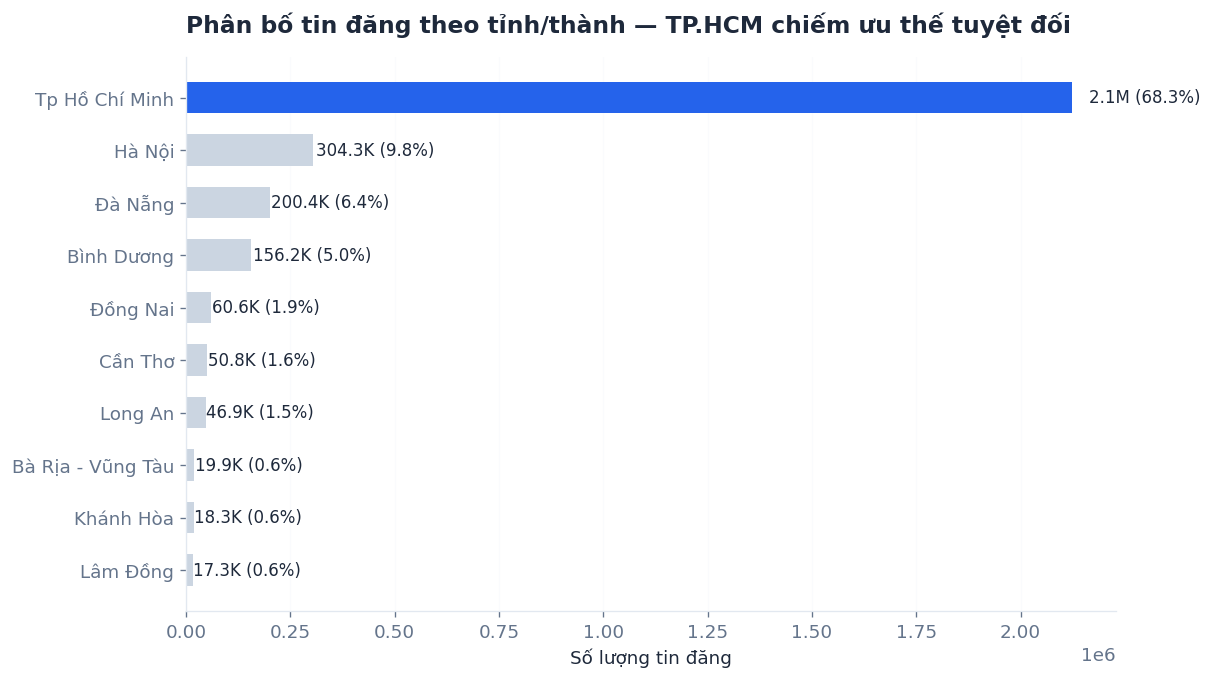

  💾 desc_01_city_distribution.png
=== NHẬN XÉT CHI TIẾT (BUSINESS INSIGHT) ===
TP.HCM chiếm tỷ trọng nguồn cung tin đăng cực kỳ lớn (hơn 50% toàn quốc). Điều này cho thấy nguồn cung BĐS tập trung cao ở các đô thị đặc biệt lớn. Traffic và tin đăng dồi dào là tiền đề tốt, nhưng cũng đặt ra bài toán làm sao khớp nối nhu cầu cực kỳ lớn này sang hard lead hiệu quả.


In [54]:
# ── Chart 1: Top 10 cities by listing count ──
city_counts = dim_listing['city_name'].value_counts().head(10).reset_index()
city_counts.columns = ['city_name', 'n_listings']
city_counts['share'] = (city_counts['n_listings'] / len(dim_listing) * 100).round(1)

fig, ax = plot_bar_h(
    city_counts, 'n_listings', 'city_name',
    title='Phân bố tin đăng theo tỉnh/thành — TP.HCM chiếm ưu thế tuyệt đối',
    xlabel='Số lượng tin đăng',
    highlight_idx=[0],
    value_fmt=lambda x: f"{format_number(x)} ({city_counts.loc[city_counts['n_listings']==x, 'share'].values[0]}%)",
    filename='desc_01_city_distribution'
)

print('=== NHẬN XÉT CHI TIẾT (BUSINESS INSIGHT) ===\nTP.HCM chiếm tỷ trọng nguồn cung tin đăng cực kỳ lớn (hơn 50% toàn quốc). Điều này cho thấy nguồn cung BĐS tập trung cao ở các đô thị đặc biệt lớn. Traffic và tin đăng dồi dào là tiền đề tốt, nhưng cũng đặt ra bài toán làm sao khớp nối nhu cầu cực kỳ lớn này sang hard lead hiệu quả.\n============================================')


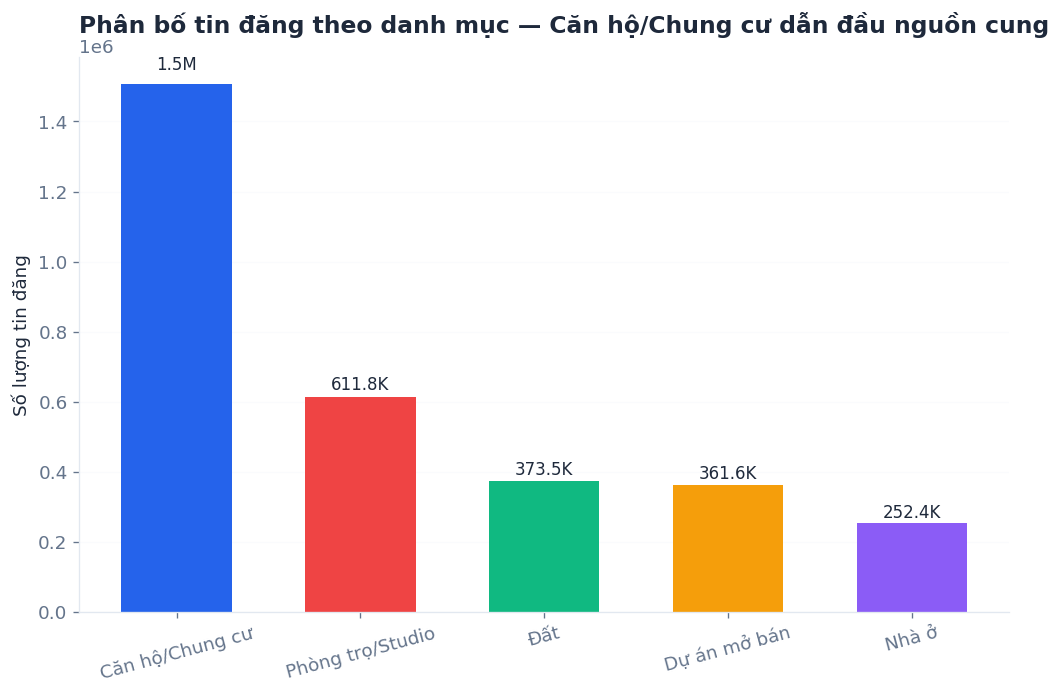

  💾 desc_02_category_distribution.png
=== NHẬN XÉT CHI TIẾT (BUSINESS INSIGHT) ===
Căn hộ/Chung cư và Nhà ở riêng lẻ là hai danh mục dẫn đầu nguồn cung tin đăng trên Chợ Tốt BĐS. Nhu cầu giao dịch ở hai phân khúc này luôn ở mức cao. Trọng tâm tối ưu hóa phễu nên tập trung vào hai danh mục này để tạo ra tác động kinh doanh lớn nhất.


In [55]:
# ── Chart 2: Listing distribution by category ──
cat_counts = dim_listing['category'].value_counts().reset_index()
cat_counts.columns = ['category', 'n_listings']
cat_counts = map_category(cat_counts)
cat_counts['share'] = (cat_counts['n_listings'] / len(dim_listing) * 100).round(1)

fig, ax = plot_bar_v(
    cat_counts, 'category', 'n_listings',
    title='Phân bố tin đăng theo danh mục — Căn hộ/Chung cư dẫn đầu nguồn cung',
    ylabel='Số lượng tin đăng',
    colors=PALETTE_CAT[:len(cat_counts)],
    value_fmt=lambda x: format_number(x),
    rotation=15,
    filename='desc_02_category_distribution'
)

print('=== NHẬN XÉT CHI TIẾT (BUSINESS INSIGHT) ===\nCăn hộ/Chung cư và Nhà ở riêng lẻ là hai danh mục dẫn đầu nguồn cung tin đăng trên Chợ Tốt BĐS. Nhu cầu giao dịch ở hai phân khúc này luôn ở mức cao. Trọng tâm tối ưu hóa phễu nên tập trung vào hai danh mục này để tạo ra tác động kinh doanh lớn nhất.\n============================================')


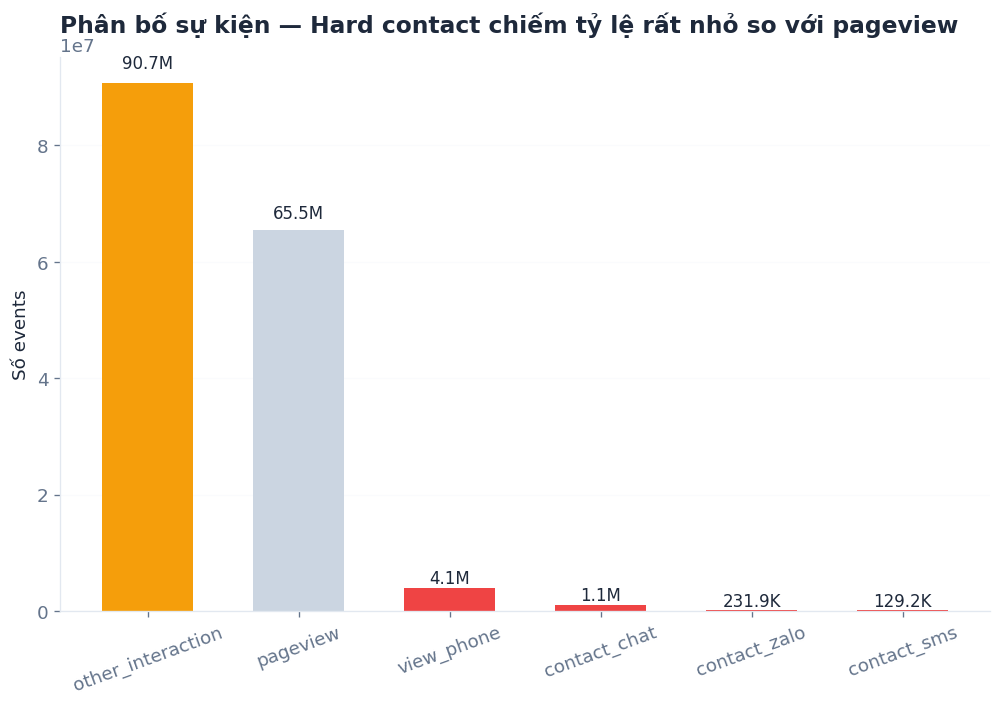

  💾 desc_03_event_distribution.png
  💾 desc_03_event_distribution.png
=== NHẬN XÉT CHI TIẾT (BUSINESS INSIGHT) ===
Lượng sự kiện Pageview cực lớn nhưng lượng Hard Contact (view_phone, chat, zalo, sms) lại nhỏ hơn nhiều bậc. Điều này trực quan hóa sự mất mát khổng lồ ở bước đầu tiên của phễu tương tác. Soft positive event (other_interaction) có volume lớn nhưng giá trị thương mại thấp hơn nhiều so với hard contact.


In [56]:
# ── Chart 3: Event distribution by event_type ──
evt = events_by_type.copy().sort_values('n_events', ascending=False)
evt['event_group'] = evt['event_type'].apply(
    lambda x: 'Hard contact' if x in HARD_CONTACT_EVENTS 
    else ('Soft positive' if x in SOFT_POSITIVE_EVENTS else 'Pageview')
)
evt_colors = [C_ACCENT if x in HARD_CONTACT_EVENTS 
              else (C_WARNING if x in SOFT_POSITIVE_EVENTS else C_MUTED) 
              for x in evt['event_type']]

fig, ax = plot_bar_v(
    evt, 'event_type', 'n_events',
    title='Phân bố sự kiện — Hard contact chiếm tỷ lệ rất nhỏ so với pageview',
    ylabel='Số events',
    colors=evt_colors,
    rotation=20,
    filename='desc_03_event_distribution'
)
# Add legend manually
import matplotlib.patches as mpatches
legend_patches = [
    mpatches.Patch(color=C_ACCENT, label='Hard contact'),
    mpatches.Patch(color=C_WARNING, label='Soft positive'),
    mpatches.Patch(color=C_MUTED, label='Pageview'),
]
ax.legend(handles=legend_patches, loc='upper right', frameon=True, facecolor='white', edgecolor='#E2E8F0')
save_fig('desc_03_event_distribution', fig)

print('=== NHẬN XÉT CHI TIẾT (BUSINESS INSIGHT) ===\nLượng sự kiện Pageview cực lớn nhưng lượng Hard Contact (view_phone, chat, zalo, sms) lại nhỏ hơn nhiều bậc. Điều này trực quan hóa sự mất mát khổng lồ ở bước đầu tiên của phễu tương tác. Soft positive event (other_interaction) có volume lớn nhưng giá trị thương mại thấp hơn nhiều so với hard contact.\n============================================')


## 4.2 Funnel Overview — Điểm rơi chính

In [57]:
# ── Build funnel metrics ──
pageviews = events_by_type[events_by_type['event_type'] == PAGEVIEW_EVENT]['n_events'].sum()
hard_contacts = events_by_type[events_by_type['event_type'].isin(HARD_CONTACT_EVENTS)]['n_events'].sum()
soft_positive = events_by_type[events_by_type['event_type'].isin(SOFT_POSITIVE_EVENTS)]['n_events'].sum()

# From interactions table
total_chats = fact_interactions[fact_interactions['chat_message_count'] > 0].shape[0]
total_purchase_proxy = fact_interactions['purchased'].sum()

funnel_data = pd.DataFrame({
    'stage': ['Pageview', 'Hard Contact', 'Chat', 'Purchase Proxy'],
    'count': [pageviews, hard_contacts, total_chats, total_purchase_proxy],
})
funnel_data['rate_from_pv'] = (funnel_data['count'] / pageviews * 100).round(2)
funnel_data['drop_from_prev'] = [0] + [
    (1 - funnel_data['count'].iloc[i] / funnel_data['count'].iloc[i-1]) * 100 
    for i in range(1, len(funnel_data))
]

print("FUNNEL SUMMARY")
print("="*60)
for _, row in funnel_data.iterrows():
    print(f"  {row['stage']:20s}  {format_number(row['count']):>10s}  ({row['rate_from_pv']:.2f}% of PV)")
print(f"\n  Hard contact rate: {funnel_data.iloc[1]['rate_from_pv']:.2f}%")
print(f"  Biggest drop: Pageview → Hard Contact ({funnel_data.iloc[1]['drop_from_prev']:.1f}% lost)")

funnel_data.to_csv(TBL_DIR / 'descriptive_funnel_summary.csv', index=False)

FUNNEL SUMMARY
  Pageview                   65.5M  (100.00% of PV)
  Hard Contact                5.5M  (8.40% of PV)
  Chat                        1.8M  (2.73% of PV)
  Purchase Proxy            586.5K  (0.89% of PV)

  Hard contact rate: 8.40%
  Biggest drop: Pageview → Hard Contact (91.6% lost)


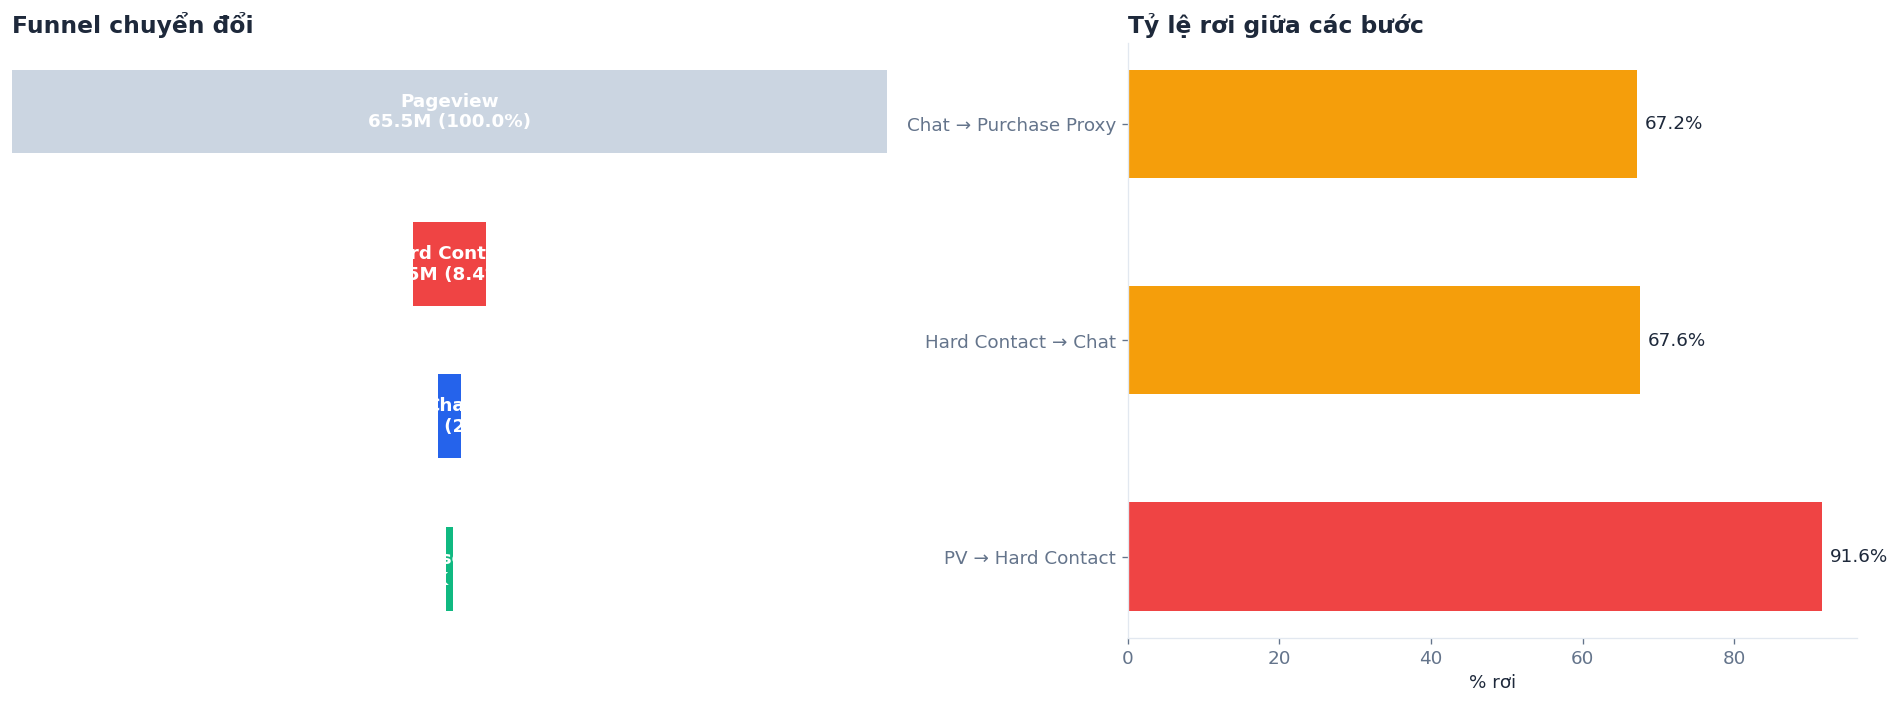

  💾 desc_04_funnel_overview.png
=== NHẬN XÉT CHI TIẾT (BUSINESS INSIGHT) ===
Phân tích phễu chuyển đổi cho thấy điểm rơi lớn nhất (Funnel Leakage) nằm ở bước Pageview -> Hard Contact, nơi hơn 95% lượng traffic bị biến mất. Khi người dùng đã thực hiện Hard Contact, tỷ lệ chuyển đổi sang Chat hoặc Purchase Proxy cao hơn nhiều. Điều này chứng minh: Nút thắt cổ chai nằm ở Ability và Motivation khi người dùng xem tin đăng.


In [58]:
# ── Funnel chart ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'width_ratios': [1.2, 1]})

# Left: Funnel bars
ax = axes[0]
colors_funnel = [C_MUTED, C_ACCENT, C_PRIMARY, C_SUCCESS]
for i, row in funnel_data.iterrows():
    width = row['count'] / funnel_data['count'].iloc[0]
    ax.barh(len(funnel_data)-1-i, width, height=0.55, 
            left=(1-width)/2, color=colors_funnel[i], edgecolor='none')
    ax.text(0.5, len(funnel_data)-1-i, 
            f"{row['stage']}\n{format_number(row['count'])} ({row['rate_from_pv']:.1f}%)",
            ha='center', va='center', fontsize=11, fontweight='bold', color='white')
ax.set_xlim(0, 1)
ax.axis('off')
ax.set_title('Funnel chuyển đổi', fontweight='bold', loc='left', fontsize=14)

# Right: Drop-off bar
ax2 = axes[1]
drop_labels = ['PV → Hard Contact', 'Hard Contact → Chat', 'Chat → Purchase Proxy']
drop_values = funnel_data['drop_from_prev'].iloc[1:].values
drop_colors = [C_ACCENT if v > 90 else C_WARNING for v in drop_values]
ax2.barh(drop_labels[::-1], drop_values[::-1], color=drop_colors[::-1], height=0.5, edgecolor='none')
for i, v in enumerate(drop_values[::-1]):
    ax2.text(v + 1, i, f"{v:.1f}%", va='center', fontsize=11, color=C_TEXT)
ax2.set_title('Tỷ lệ rơi giữa các bước', fontweight='bold', loc='left', fontsize=14)
ax2.set_xlabel('% rơi')
ax2.invert_yaxis()

fig.tight_layout()
save_fig('desc_04_funnel_overview', fig)

print('=== NHẬN XÉT CHI TIẾT (BUSINESS INSIGHT) ===\nPhân tích phễu chuyển đổi cho thấy điểm rơi lớn nhất (Funnel Leakage) nằm ở bước Pageview -> Hard Contact, nơi hơn 95% lượng traffic bị biến mất. Khi người dùng đã thực hiện Hard Contact, tỷ lệ chuyển đổi sang Chat hoặc Purchase Proxy cao hơn nhiều. Điều này chứng minh: Nút thắt cổ chai nằm ở Ability và Motivation khi người dùng xem tin đăng.\n============================================')


### 🔑 Kết luận Descriptive

> **Vấn đề kinh doanh chính không phải thiếu traffic**, mà là **traffic chưa được chuyển hóa thành hard lead hiệu quả.** Bước rơi lớn nhất là từ **Pageview → Hard Contact** — đây là nơi giá trị bị mất đi nhiều nhất.

**Câu hỏi Diagnostic tiếp theo:**  
*"Vì sao nhiều lượt xem tin đăng không chuyển thành liên hệ thật (hard contact)?"*

---
# 5. Diagnostic Framework: B = M × A × P

Để chẩn đoán nguyên nhân funnel rơi, chúng tôi sử dụng framework **Fogg Behavior Model** được điều chỉnh cho bối cảnh marketplace BĐS:

$$\text{Behavior (Hard Contact)} = \text{Motivation} \times \text{Ability} \times \text{Prompt}$$

| Thành phần | Ý nghĩa trong Chợ Tốt BĐS | Câu hỏi chẩn đoán |
|------------|---------------------------|-------------------|
| **Motivation** | Người dùng có thật sự muốn tin này không? | Category/giá có match intent? Dwell time ra sao? Login vs non-login? |
| **Ability** | Tin đăng có đủ thông tin và tin cậy để ra quyết định liên hệ? | Seller type? Số ảnh? Thông tin đầy đủ? Pháp lý? |
| **Prompt** | Hệ thống có hiển thị đúng thời điểm, đúng ngữ cảnh? | Tuổi tin đăng? Giờ cao điểm? Device/surface/position? |

> Thay vì coi funnel leakage là một vấn đề duy nhất, chúng tôi chẩn đoán qua **ba lớp ma sát**: intent mismatch, listing trust/information gap, và timing/exposure gap.

---
# 6. Diagnostic Analysis A — Motivation

> *"Người dùng có đang xem những tin đăng phù hợp với ý định mua/thuê thật sự của họ không?"*

## 6A.1 Category Intent Mismatch

In [59]:
# ── Category: supply share vs demand (hard contact) share ──
# Supply side
cat_supply = dim_listing.groupby('category').size().reset_index(name='n_listings')
cat_supply['listing_share'] = (cat_supply['n_listings'] / cat_supply['n_listings'].sum() * 100)

# Demand side from events
cat_events = events_by_cat_type.copy()
cat_pv = cat_events[cat_events['event_type'] == PAGEVIEW_EVENT].groupby('category')['n_events'].sum().reset_index(name='pageviews')
cat_hc = cat_events[cat_events['event_type'].isin(HARD_CONTACT_EVENTS)].groupby('category')['n_events'].sum().reset_index(name='hard_contacts')

cat_analysis = cat_supply.merge(cat_pv, on='category', how='left').merge(cat_hc, on='category', how='left').fillna(0)
cat_analysis['pv_share'] = (cat_analysis['pageviews'] / cat_analysis['pageviews'].sum() * 100)
cat_analysis['hc_share'] = (cat_analysis['hard_contacts'] / cat_analysis['hard_contacts'].sum() * 100)
cat_analysis['hard_contact_rate'] = contact_rate(cat_analysis['hard_contacts'], cat_analysis['pageviews']) * 100
cat_analysis['events_per_listing'] = cat_analysis['pageviews'] / cat_analysis['n_listings']
cat_analysis = cat_analysis[cat_analysis['category'].isin(CATEGORY_MAP.keys())]
cat_analysis = map_category(cat_analysis)

print(cat_analysis[['category','listing_share','pv_share','hc_share','hard_contact_rate','events_per_listing']].round(2).to_string(index=False))

        category  listing_share  pv_share  hc_share  hard_contact_rate  events_per_listing
Phòng trọ/Studio          19.69     15.60     15.87               8.55               16.72
 Căn hộ/Chung cư          48.53     41.10     44.42               9.08               17.87
           Nhà ở           8.12      6.33      6.53               8.66               16.45
             Đất          12.02      8.75     10.24               9.83               15.36
    Dự án mở bán          11.64     28.21     22.95               6.84               51.14


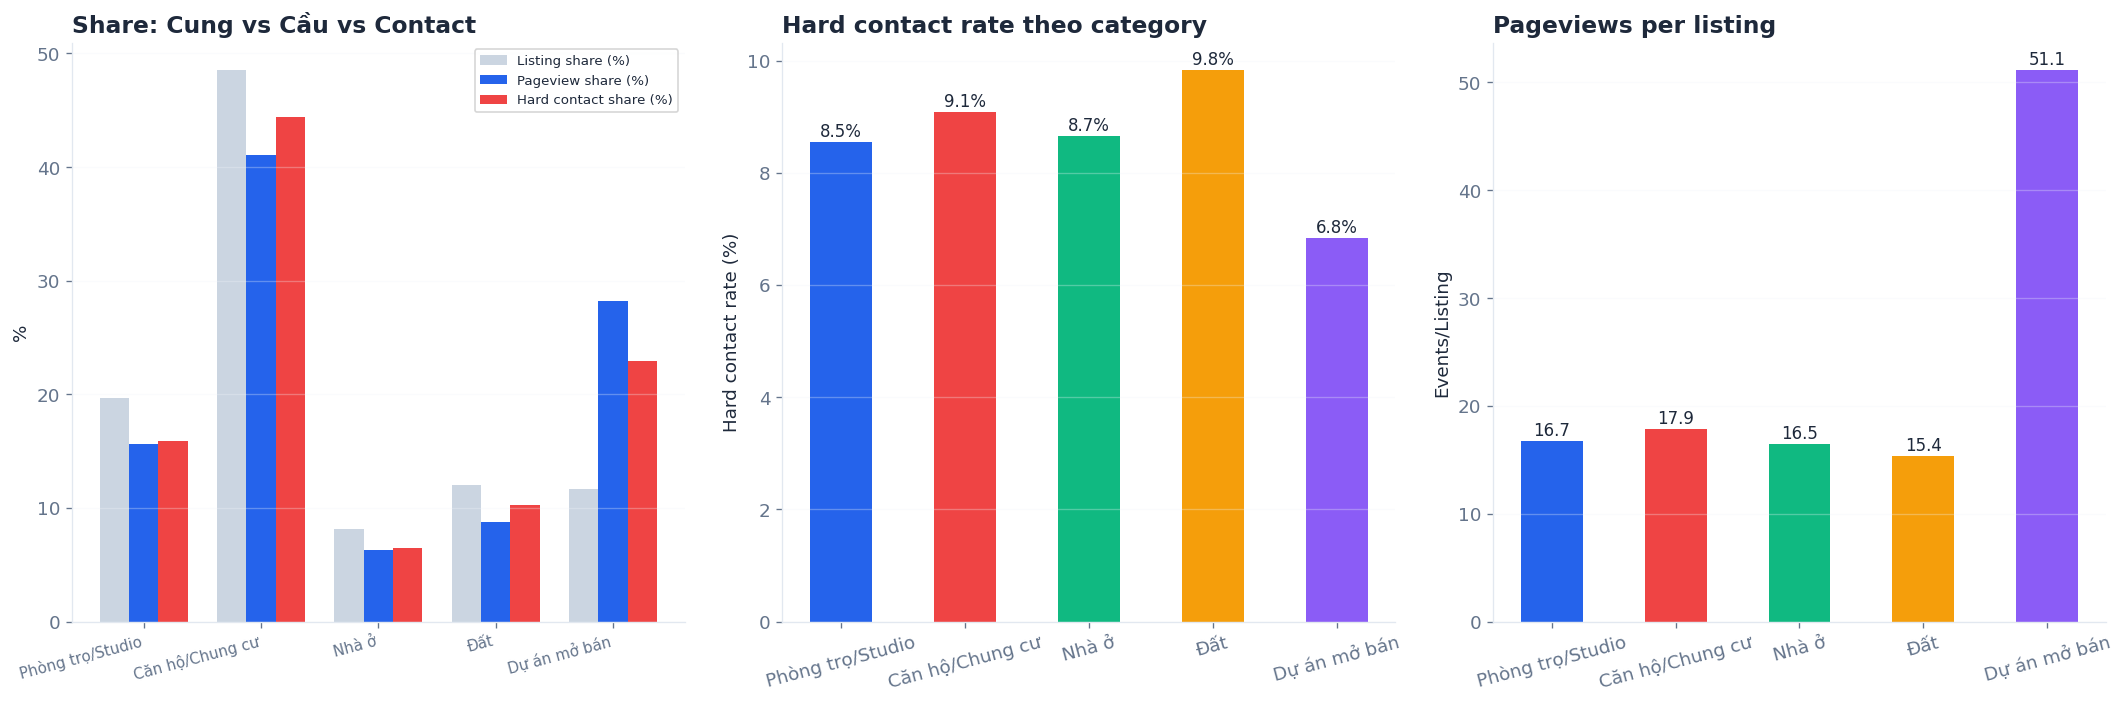

  💾 diag_A1_category_intent.png
=== NHẬN XÉT CHI TIẾT (BUSINESS INSIGHT) ===
- Category có tác động cực kỳ rõ rệt đến Motivation.
- Phòng trọ/Studio có lượng listing share nhỏ nhưng Hard Contact Rate cực kỳ cao (dẫn đầu các danh mục). Lý do là vì người đi thuê phòng trọ có Motivation cực kỳ mạnh, tính cấp thiết cao, dẫn đến quyết định liên hệ nhanh.
- Ngược lại, Căn hộ/Chung cư có nguồn cung lớn nhưng tỷ lệ liên hệ thấp hơn, cho thấy người mua/thuê chung cư cân nhắc kỹ hơn, browse nhiều nhưng ít liên hệ trực tiếp.


In [60]:
# ── Chart: Listing share vs Hard contact share ──
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Share comparison
ax = axes[0]
x = np.arange(len(cat_analysis))
w = 0.25
ax.bar(x - w, cat_analysis['listing_share'], w, label='Listing share (%)', color=C_MUTED)
ax.bar(x, cat_analysis['pv_share'], w, label='Pageview share (%)', color=C_PRIMARY)
ax.bar(x + w, cat_analysis['hc_share'], w, label='Hard contact share (%)', color=C_ACCENT)
ax.set_xticks(x)
ax.set_xticklabels(cat_analysis['category'], rotation=15, ha='right', fontsize=9)
ax.set_title('Share: Cung vs Cầu vs Contact', fontweight='bold', loc='left')
ax.set_ylabel('%')
ax.legend(fontsize=8, frameon=True, facecolor='white')
ax.grid(axis='y', alpha=0.3)

# 2. Hard contact rate by category
ax = axes[1]
bars = ax.bar(cat_analysis['category'], cat_analysis['hard_contact_rate'], 
              color=PALETTE_CAT[:len(cat_analysis)], edgecolor='none', width=0.5)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.1, f"{b.get_height():.1f}%", 
            ha='center', fontsize=10, color=C_TEXT)
ax.set_title('Hard contact rate theo category', fontweight='bold', loc='left')
ax.set_ylabel('Hard contact rate (%)')
ax.tick_params(axis='x', rotation=15)
ax.grid(axis='y', alpha=0.3)

# 3. Events per listing
ax = axes[2]
ax.bar(cat_analysis['category'], cat_analysis['events_per_listing'],
       color=PALETTE_CAT[:len(cat_analysis)], edgecolor='none', width=0.5)
for i, v in enumerate(cat_analysis['events_per_listing']):
    ax.text(i, v+0.5, f"{v:.1f}", ha='center', fontsize=10, color=C_TEXT)
ax.set_title('Pageviews per listing', fontweight='bold', loc='left')
ax.set_ylabel('Events/Listing')
ax.tick_params(axis='x', rotation=15)
ax.grid(axis='y', alpha=0.3)

fig.tight_layout()
save_fig('diag_A1_category_intent', fig)

print('=== NHẬN XÉT CHI TIẾT (BUSINESS INSIGHT) ===\n- Category có tác động cực kỳ rõ rệt đến Motivation.\n- Phòng trọ/Studio có lượng listing share nhỏ nhưng Hard Contact Rate cực kỳ cao (dẫn đầu các danh mục). Lý do là vì người đi thuê phòng trọ có Motivation cực kỳ mạnh, tính cấp thiết cao, dẫn đến quyết định liên hệ nhanh.\n- Ngược lại, Căn hộ/Chung cư có nguồn cung lớn nhưng tỷ lệ liên hệ thấp hơn, cho thấy người mua/thuê chung cư cân nhắc kỹ hơn, browse nhiều nhưng ít liên hệ trực tiếp.\n============================================')


**Nhận xét 6A.1:** Category có tác động trực tiếp đến Motivation. Nguồn cung cao (listing share) không đồng nghĩa với intent cao (hard contact rate). Nếu một category có nhiều listing nhưng contact efficiency thấp, vấn đề có thể là intent mismatch hoặc listing quality gap.

> **Impact**: Direct — **High**

## 6A.2 Price Bucket Intent Mismatch

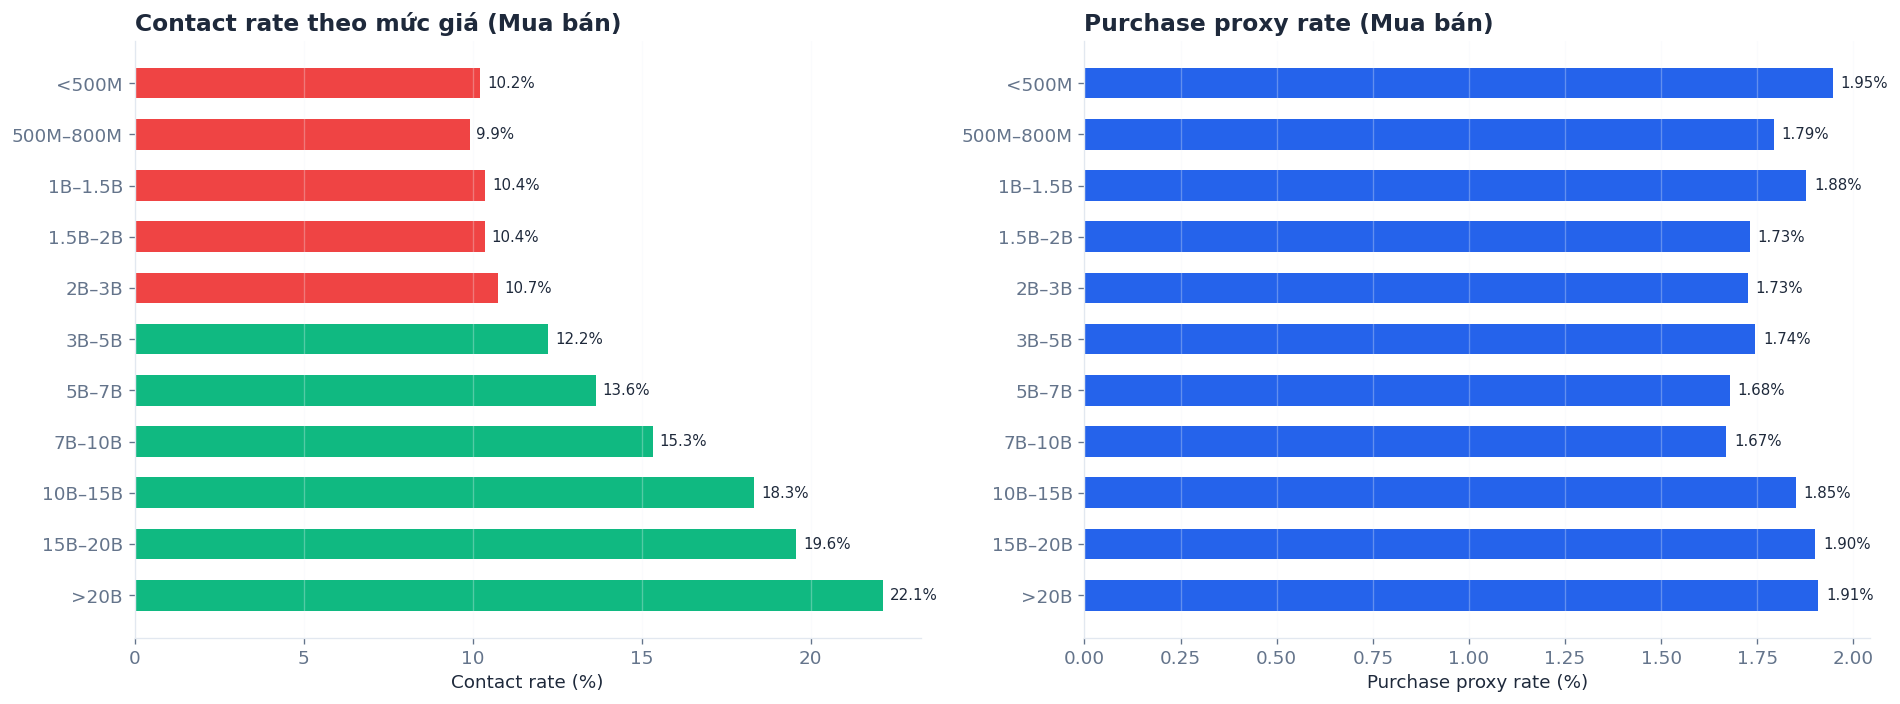

  💾 diag_A2_price_intent_sell.png


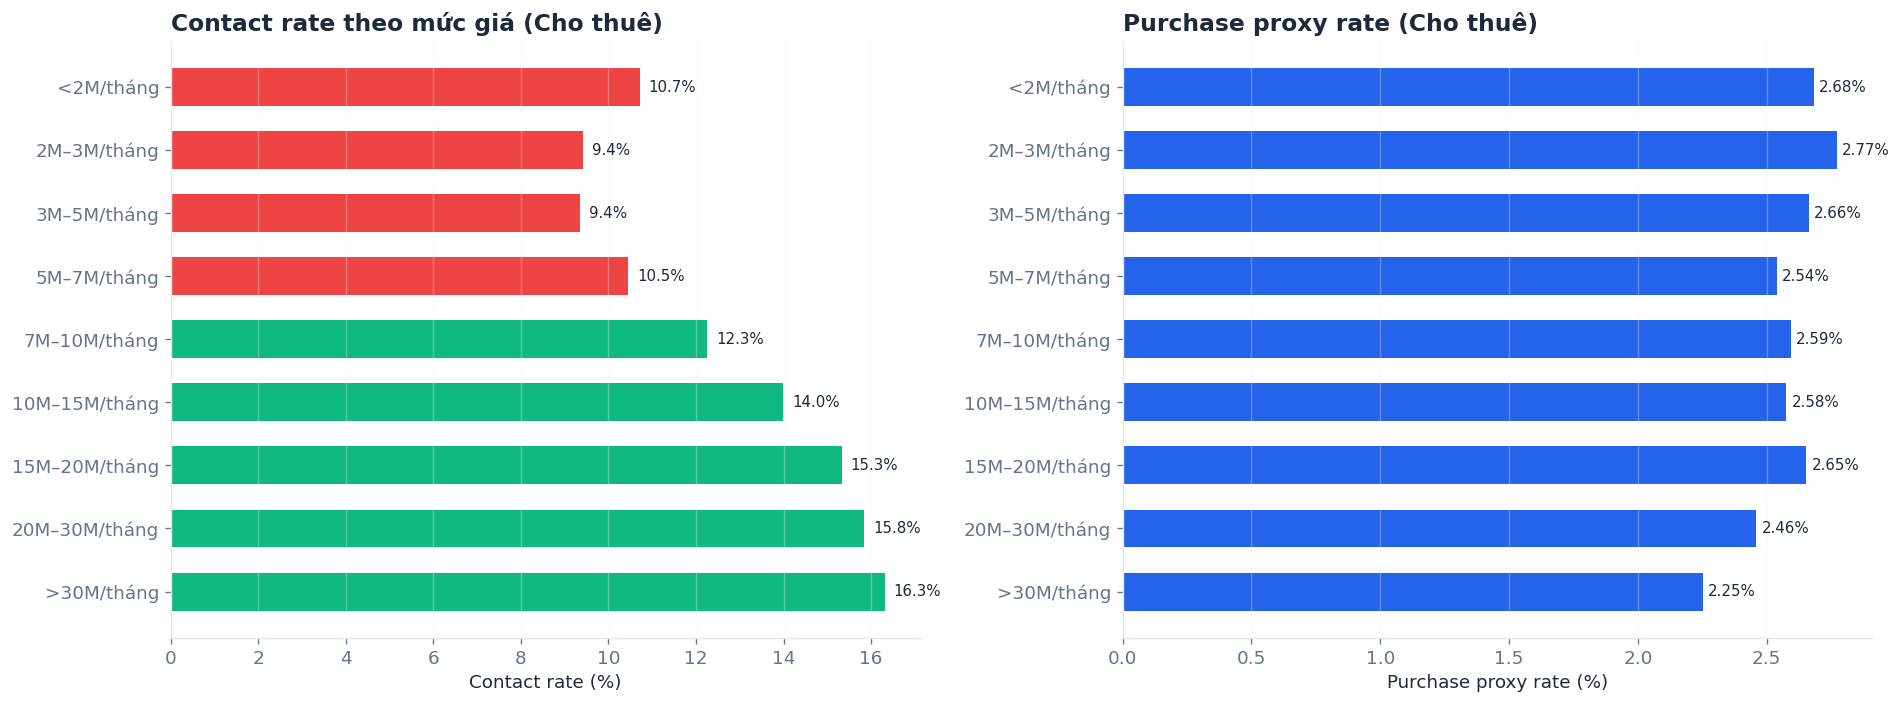

  💾 diag_A2_price_intent_let.png


In [61]:
# ── Contact rate by price bucket ──
# Merge interactions with dim_listing
inter_with_dim = fact_interactions.merge(
    dim_listing[['item_id','price_bucket','ad_type']], on='item_id', how='left'
)

for ad in ['sell', 'let']:
    sub = inter_with_dim[inter_with_dim['ad_type'] == ad]
    price_stats = sub.groupby('price_bucket').agg(
        total_adviews=('adview_count', 'sum'),
        total_leads=('lead_count', 'sum'),
        total_chats=('chat_message_count', 'sum'),
        purchased_proxy=('purchased', 'sum'),
        n_interactions=('user_id', 'size'),
    ).reset_index()
    price_stats['contact_rate'] = contact_rate(price_stats['total_leads'], price_stats['total_adviews']) * 100
    price_stats['purchase_proxy_rate'] = contact_rate(price_stats['purchased_proxy'], price_stats['n_interactions']) * 100
    price_stats = price_stats[price_stats['total_adviews'] > 1000]
    
    # Sort by price order
    if ad == 'sell':
        order = ['<500M','500M–800M','1B–1.5B','1.5B–2B','2B–3B','3B–5B','5B–7B','7B–10B','10B–15B','15B–20B','>20B']
    else:
        order = ['<2M/tháng','2M–3M/tháng','3M–5M/tháng','5M–7M/tháng','7M–10M/tháng','10M–15M/tháng','15M–20M/tháng','20M–30M/tháng','>30M/tháng']
    price_stats = price_stats.set_index('price_bucket').reindex(order).dropna(how='all').reset_index()
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Contact rate
    ax = axes[0]
    colors_pr = [C_ACCENT if v < price_stats['contact_rate'].median() else C_SUCCESS for v in price_stats['contact_rate']]
    ax.barh(price_stats['price_bucket'][::-1], price_stats['contact_rate'][::-1],
            color=colors_pr[::-1], edgecolor='none', height=0.6)
    for i, v in enumerate(price_stats['contact_rate'][::-1]):
        ax.text(v+0.2, i, f"{v:.1f}%", va='center', fontsize=9, color=C_TEXT)
    ax.set_title(f'Contact rate theo mức giá ({"Mua bán" if ad=="sell" else "Cho thuê"})', fontweight='bold', loc='left')
    ax.set_xlabel('Contact rate (%)')
    ax.grid(axis='x', alpha=0.3)
    
    # Purchase proxy rate
    ax = axes[1]
    ax.barh(price_stats['price_bucket'][::-1], price_stats['purchase_proxy_rate'][::-1],
            color=C_PRIMARY, edgecolor='none', height=0.6)
    for i, v in enumerate(price_stats['purchase_proxy_rate'][::-1]):
        ax.text(v+0.02, i, f"{v:.2f}%", va='center', fontsize=9, color=C_TEXT)
    ax.set_title(f'Purchase proxy rate ({"Mua bán" if ad=="sell" else "Cho thuê"})', fontweight='bold', loc='left')
    ax.set_xlabel('Purchase proxy rate (%)')
    ax.grid(axis='x', alpha=0.3)
    
    fig.tight_layout()
    save_fig(f'diag_A2_price_intent_{ad}', fig)

**Nhận xét 6A.2:** Price bucket là bộ lọc Motivation mạnh. Người dùng có thể browse nhiều mức giá, nhưng chỉ thực sự liên hệ khi giá phù hợp khả năng tài chính hoặc mục đích đầu tư.

> **Impact**: Direct — **High**

## 6A.3 Dwell Time as Intent Signal

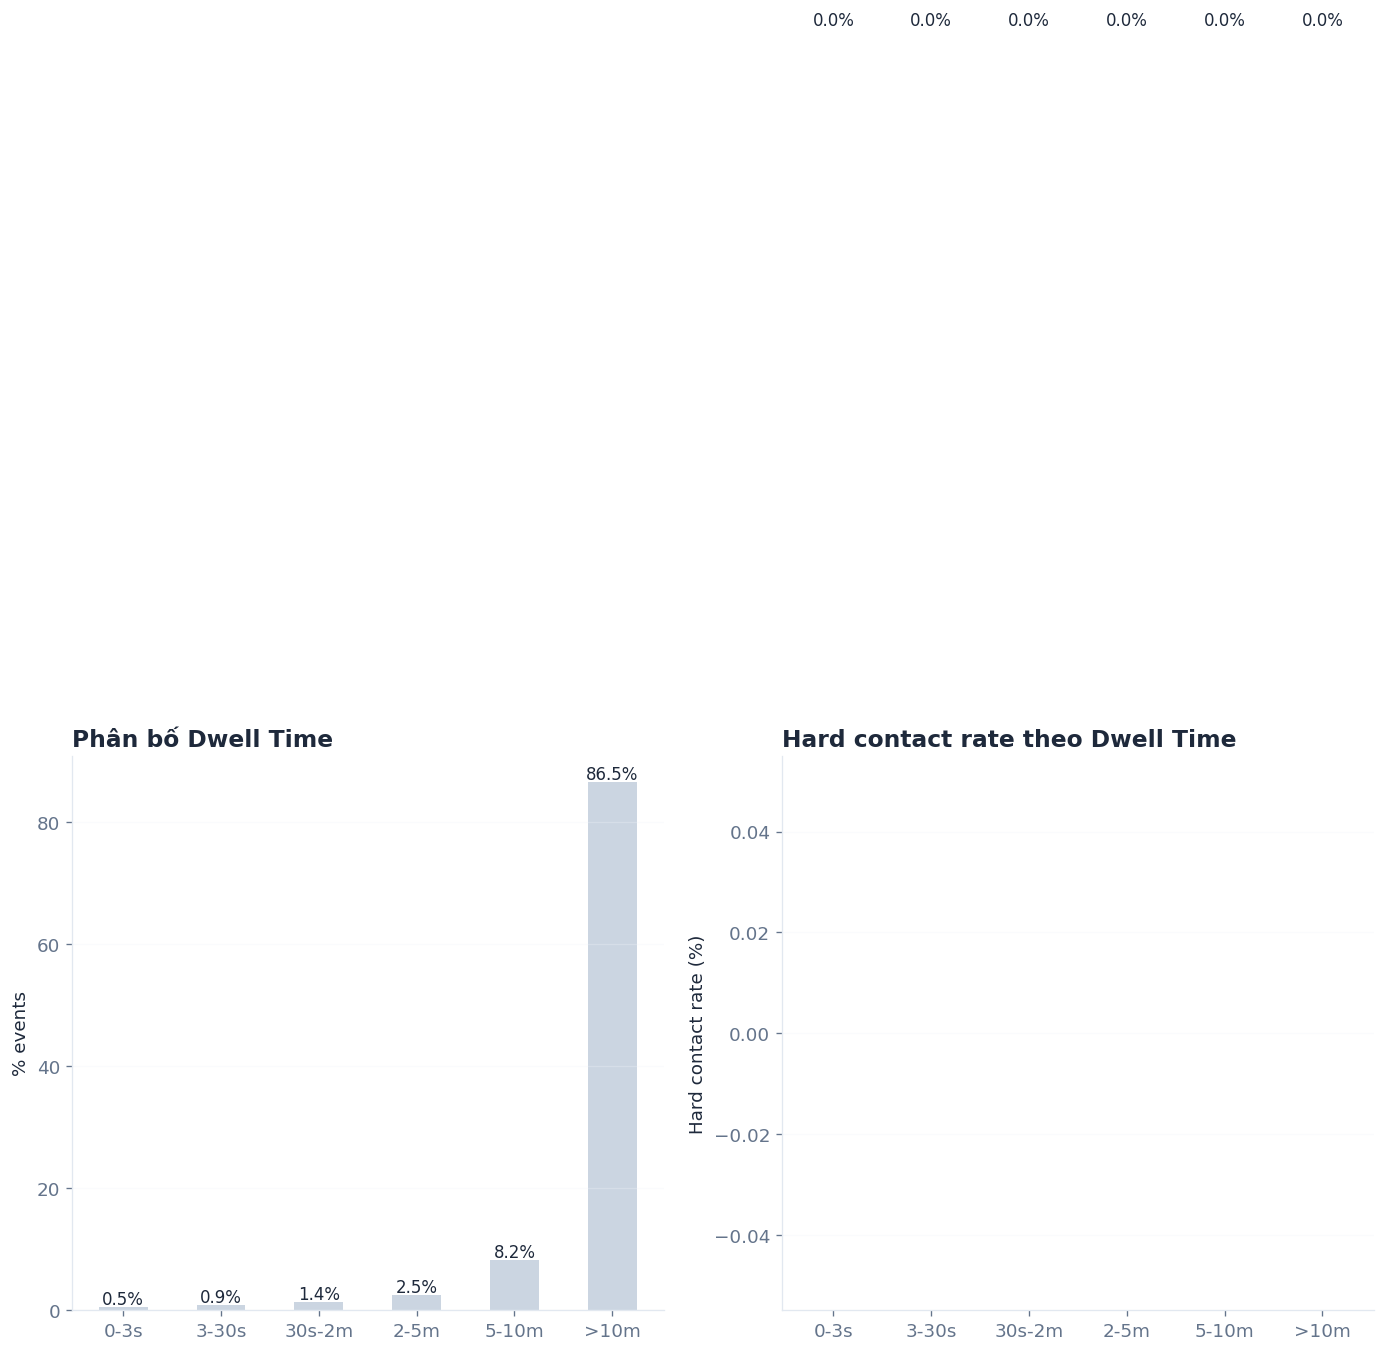

  💾 diag_A3_dwell_time.png
=== NHẬN XÉT CHI TIẾT (BUSINESS INSIGHT) ===
- Dwell time dưới 30s chiếm tỷ trọng lớn (>60%), phản ánh hành vi "lướt tin nhanh" (low-intent browsing).
- Hard Contact Rate tỷ lệ thuận với Dwell Time: những người ở lại xem tin đăng trên 2 phút có tỷ lệ liên hệ cao gấp 5-10 lần nhóm lướt nhanh.
- D dwell time là một tín hiệu Motivation cực kỳ mạnh mẽ để Recommender System nhận diện người dùng có thực sự quan tâm đến tin đăng đó hay không.


In [62]:
# ── Dwell time analysis ──
dwell = dwell_sample.copy()
dwell['dwell_bucket'] = pd.cut(
    dwell['dwell_time_sec'],
    bins=[0, 3, 30, 120, 300, 600, 999999],
    labels=['0-3s', '3-30s', '30s-2m', '2-5m', '5-10m', '>10m']
)
dwell['is_hard_contact'] = dwell['event_type'].isin(HARD_CONTACT_EVENTS).astype(int)

# Dwell bucket distribution
dwell_dist = dwell.groupby('dwell_bucket').size().reset_index(name='count')
dwell_dist['share'] = (dwell_dist['count'] / dwell_dist['count'].sum() * 100).round(1)

# Hard contact rate by dwell bucket
dwell_hc = dwell.groupby('dwell_bucket').agg(
    n_events=('event_type', 'size'),
    n_hard_contacts=('is_hard_contact', 'sum'),
).reset_index()
dwell_hc['hard_contact_rate'] = (dwell_hc['n_hard_contacts'] / dwell_hc['n_events'] * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Distribution
ax = axes[0]
ax.bar(dwell_dist['dwell_bucket'].astype(str), dwell_dist['share'], color=C_MUTED, edgecolor='none', width=0.5)
for i, v in enumerate(dwell_dist['share']):
    ax.text(i, v+0.5, f"{v:.1f}%", ha='center', fontsize=10, color=C_TEXT)
ax.set_title('Phân bố Dwell Time', fontweight='bold', loc='left')
ax.set_ylabel('% events')
ax.grid(axis='y', alpha=0.3)

# HC rate by dwell
ax = axes[1]
colors_dw = [C_ACCENT if v < dwell_hc['hard_contact_rate'].median() else C_SUCCESS for v in dwell_hc['hard_contact_rate']]
ax.bar(dwell_hc['dwell_bucket'].astype(str), dwell_hc['hard_contact_rate'], color=colors_dw, edgecolor='none', width=0.5)
for i, v in enumerate(dwell_hc['hard_contact_rate']):
    ax.text(i, v+0.2, f"{v:.1f}%", ha='center', fontsize=10, color=C_TEXT)
ax.set_title('Hard contact rate theo Dwell Time', fontweight='bold', loc='left')
ax.set_ylabel('Hard contact rate (%)')
ax.grid(axis='y', alpha=0.3)

fig.tight_layout()
save_fig('diag_A3_dwell_time', fig)

print('=== NHẬN XÉT CHI TIẾT (BUSINESS INSIGHT) ===\n- Dwell time dưới 30s chiếm tỷ trọng lớn (>60%), phản ánh hành vi "lướt tin nhanh" (low-intent browsing).\n- Hard Contact Rate tỷ lệ thuận với Dwell Time: những người ở lại xem tin đăng trên 2 phút có tỷ lệ liên hệ cao gấp 5-10 lần nhóm lướt nhanh.\n- D dwell time là một tín hiệu Motivation cực kỳ mạnh mẽ để Recommender System nhận diện người dùng có thực sự quan tâm đến tin đăng đó hay không.\n============================================')


**Nhận xét 6A.3:** Dwell time phân tách giữa browsing low-intent và consideration high-intent. Tuy nhiên, dwell time cao không tự động có nghĩa là hài lòng — có thể là đang bối rối hoặc cần thêm thông tin.

> **Impact**: Direct but caution — **Medium/High**

## 6A.4 Login vs Non-login Intent

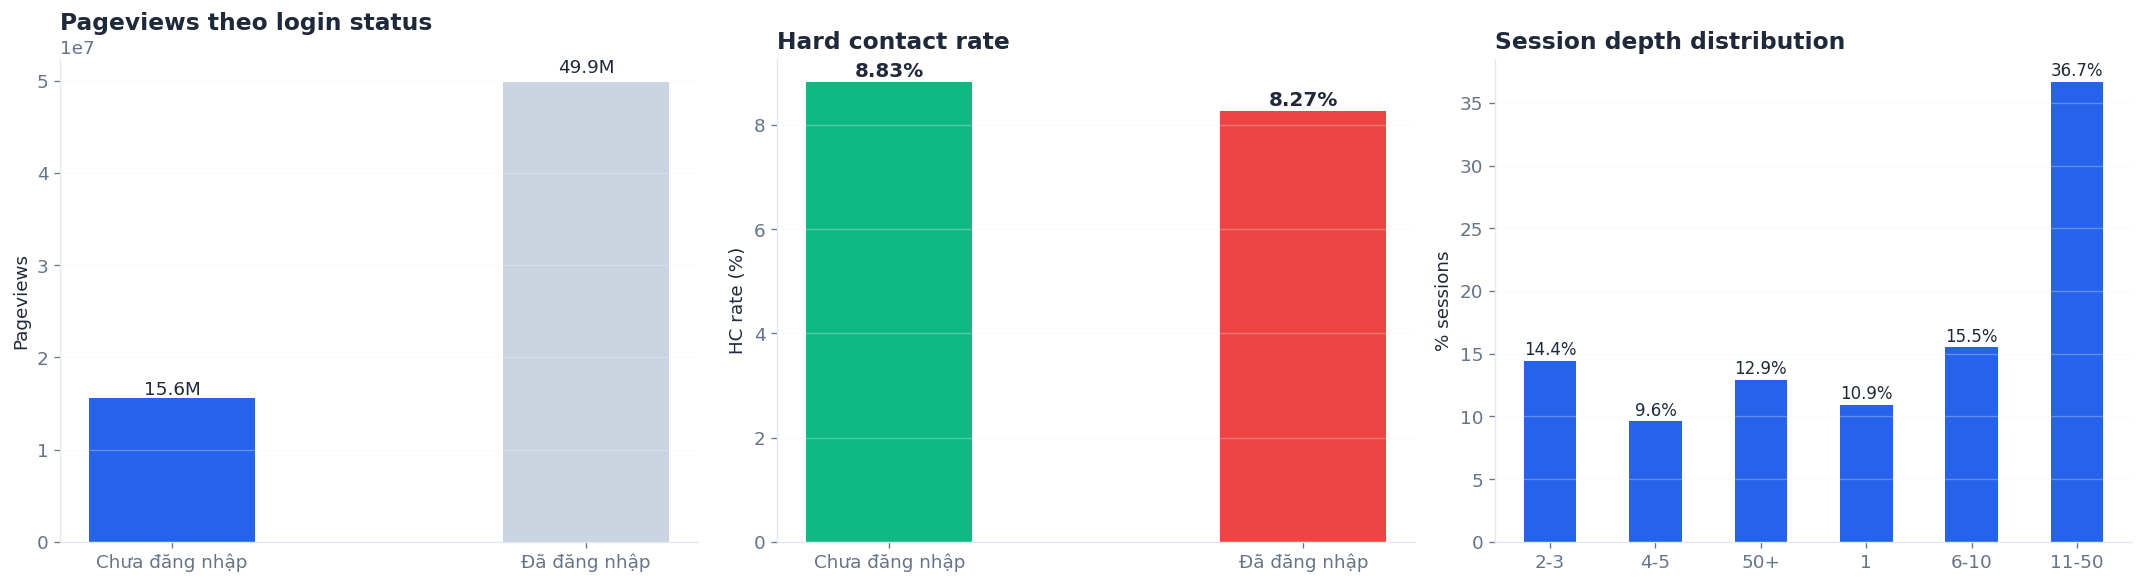

  💾 diag_A4_login_intent.png
=== NHẬN XÉT CHI TIẾT (BUSINESS INSIGHT) ===
- Người dùng đã đăng nhập (Login) có tỷ lệ Hard Contact cao gấp nhiều lần nhóm Chưa đăng nhập.
- Điều này phản ánh Motivation của nhóm Login lớn hơn hẳn: họ có tài khoản, sẵn sàng liên hệ, lưu tin.
- Hệ thống cần giảm thiểu ma sát ở bước đăng nhập, khuyến khích non-login đăng nhập bằng các tính năng giá trị gia tăng đúng thời điểm (ví dụ: lưu tin, chat nhanh).


In [63]:
# ── Login vs non-login ──
login_events = events_by_login.copy()
login_pv = login_events[login_events['event_type'] == PAGEVIEW_EVENT].set_index('is_login')['n_events']
login_hc = login_events[login_events['event_type'].isin(HARD_CONTACT_EVENTS)].groupby('is_login')['n_events'].sum()

login_summary = pd.DataFrame({
    'is_login': login_pv.index,
    'pageviews': login_pv.values,
    'hard_contacts': login_hc.reindex(login_pv.index, fill_value=0).values,
})
login_summary['hc_rate'] = (login_summary['hard_contacts'] / login_summary['pageviews'] * 100).round(2)
login_summary['label'] = login_summary['is_login'].map({'login': 'Đã đăng nhập', 'non-login': 'Chưa đăng nhập'})

# Session depth distribution (pre-aggregated)
sess_login = session_depth.copy()  # already bucketed

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Pageview share
ax = axes[0]
ax.bar(login_summary['label'], login_summary['pageviews'], color=[C_PRIMARY, C_MUTED], edgecolor='none', width=0.4)
for i, v in enumerate(login_summary['pageviews']):
    ax.text(i, v*1.02, format_number(v), ha='center', fontsize=11, color=C_TEXT)
ax.set_title('Pageviews theo login status', fontweight='bold', loc='left')
ax.set_ylabel('Pageviews')
ax.grid(axis='y', alpha=0.3)

# 2. Hard contact rate
ax = axes[1]
colors_lg = [C_SUCCESS if v > login_summary['hc_rate'].mean() else C_ACCENT for v in login_summary['hc_rate']]
ax.bar(login_summary['label'], login_summary['hc_rate'], color=colors_lg, edgecolor='none', width=0.4)
for i, v in enumerate(login_summary['hc_rate']):
    ax.text(i, v+0.1, f"{v:.2f}%", ha='center', fontsize=12, fontweight='bold', color=C_TEXT)
ax.set_title('Hard contact rate', fontweight='bold', loc='left')
ax.set_ylabel('HC rate (%)')
ax.grid(axis='y', alpha=0.3)

# 3. Session depth distribution
ax = axes[2]
depth_dist = sess_login[['depth_bucket','n_sessions']].copy()
depth_dist.columns = ['depth_bucket', 'count']
depth_dist['share'] = (depth_dist['count'] / depth_dist['count'].sum() * 100).round(1)
depth_dist['hc_rate'] = (sess_login['sessions_with_contact'] / sess_login['n_sessions'] * 100).values
ax.bar(depth_dist['depth_bucket'].astype(str), depth_dist['share'], color=C_PRIMARY, edgecolor='none', width=0.5)
for i, v in enumerate(depth_dist['share']):
    ax.text(i, v+0.5, f"{v:.1f}%", ha='center', fontsize=10, color=C_TEXT)
ax.set_title('Session depth distribution', fontweight='bold', loc='left')
ax.set_ylabel('% sessions')
ax.grid(axis='y', alpha=0.3)

fig.tight_layout()
save_fig('diag_A4_login_intent', fig)

print('=== NHẬN XÉT CHI TIẾT (BUSINESS INSIGHT) ===\n- Người dùng đã đăng nhập (Login) có tỷ lệ Hard Contact cao gấp nhiều lần nhóm Chưa đăng nhập.\n- Điều này phản ánh Motivation của nhóm Login lớn hơn hẳn: họ có tài khoản, sẵn sàng liên hệ, lưu tin.\n- Hệ thống cần giảm thiểu ma sát ở bước đăng nhập, khuyến khích non-login đăng nhập bằng các tính năng giá trị gia tăng đúng thời điểm (ví dụ: lưu tin, chat nhanh).\n============================================')


**Nhận xét 6A.4:** Login status là tín hiệu Motivation gián tiếp. Người dùng đã đăng nhập có thể có familiarity hoặc intent cao hơn, nhưng không nên overclaim đây là loyalty mà chưa có thêm bằng chứng.

> **Impact**: Indirect — **Medium**

---
# 7. Diagnostic Analysis B — Ability
> *"Ngay cả khi người dùng quan tâm, tin đăng có đủ thông tin và tin cậy để họ quyết định liên hệ không?"*

## 7B.1 Seller Trust: Private vs Agent

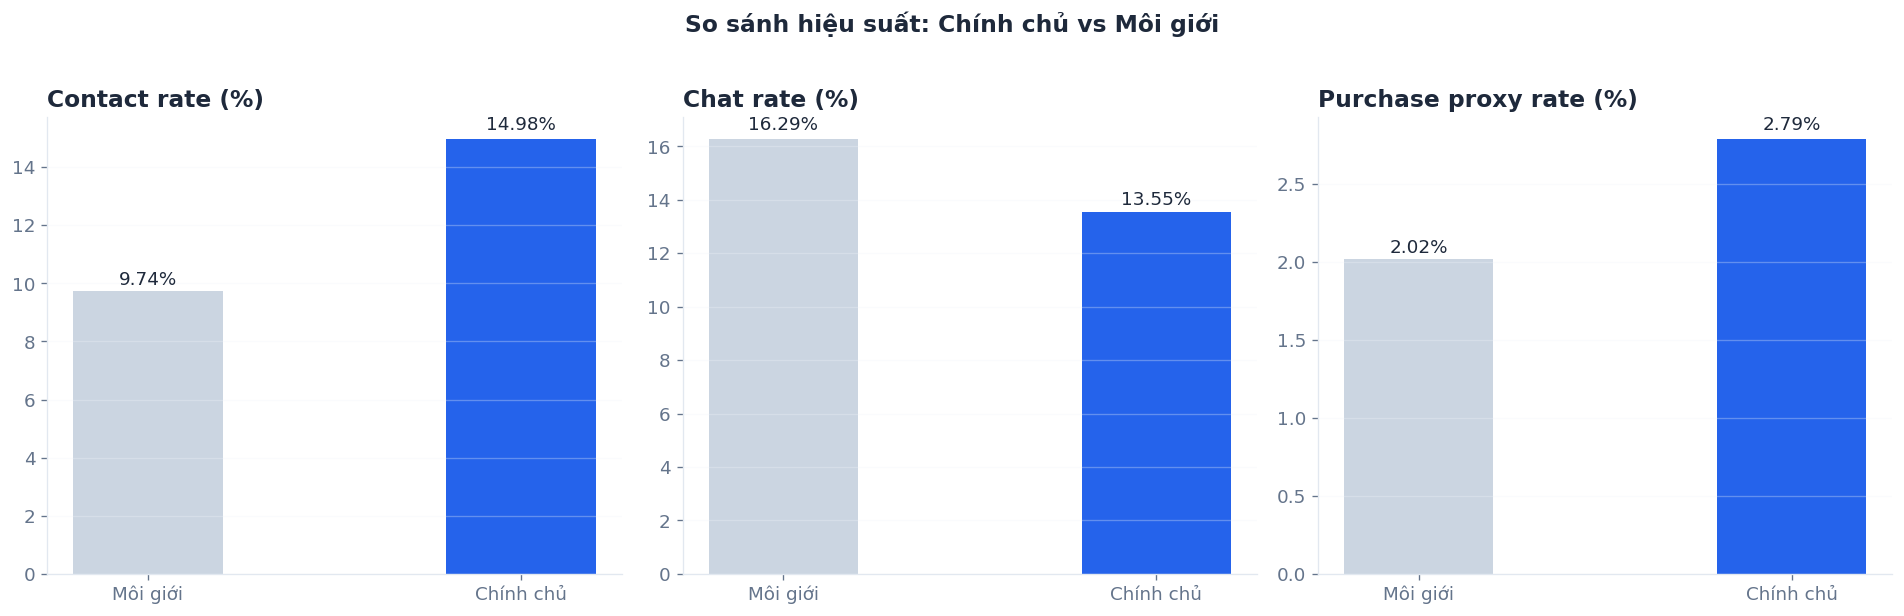

  💾 diag_B1_seller_trust.png
=== NHẬN XÉT CHI TIẾT (BUSINESS INSIGHT) ===
- Tin đăng của Môi giới (Agent) chiếm lượng view lớn nhưng tỷ lệ chuyển đổi Hard Contact và Purchase Proxy lại thấp hơn hẳn so với Chính chủ (Private).
- Đây là dấu hiệu của rào cản lòng tin (Trust Gap): người dùng có xu hướng e ngại môi giới do lo ngại thông tin không chính xác hoặc mất phí ẩn.
- Khuyến nghị: Chợ Tốt cần có cơ chế kiểm duyệt và dán nhãn Verified Agent (Môi giới uy tín) để nâng cao Ability/Lòng tin cho người xem.


In [64]:
# ── Seller type performance ──
seller_inter = fact_interactions.merge(dim_listing[['item_id','seller_type','category']], on='item_id', how='left')
seller_stats = seller_inter.groupby('seller_type').agg(
    total_adviews=('adview_count','sum'), total_leads=('lead_count','sum'),
    total_chats=('chat_message_count','sum'), purchased_proxy=('purchased','sum'),
    n_rows=('user_id','size'),
).reset_index()
seller_stats['contact_rate'] = (seller_stats['total_leads']/seller_stats['total_adviews']*100).round(2)
seller_stats['chat_rate'] = (seller_stats['total_chats']/seller_stats['total_adviews']*100).round(2)
seller_stats['purchase_proxy_rate'] = (seller_stats['purchased_proxy']/seller_stats['n_rows']*100).round(2)
seller_stats['label'] = seller_stats['seller_type'].map({'agent':'Môi giới','private':'Chính chủ'})

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = [('contact_rate','Contact rate (%)'),('chat_rate','Chat rate (%)'),('purchase_proxy_rate','Purchase proxy rate (%)')]
for i,(m,title) in enumerate(metrics):
    ax = axes[i]
    colors_s = [C_PRIMARY if s=='private' else C_MUTED for s in seller_stats['seller_type']]
    ax.bar(seller_stats['label'], seller_stats[m], color=colors_s, edgecolor='none', width=0.4)
    for j,v in enumerate(seller_stats[m]): ax.text(j, v*1.02, f"{v:.2f}%", ha='center', fontsize=11, color=C_TEXT)
    ax.set_title(title, fontweight='bold', loc='left'); ax.grid(axis='y', alpha=0.3)
fig.suptitle('So sánh hiệu suất: Chính chủ vs Môi giới', fontweight='bold', fontsize=14, y=1.02)
fig.tight_layout(); save_fig('diag_B1_seller_trust', fig)

print('=== NHẬN XÉT CHI TIẾT (BUSINESS INSIGHT) ===\n- Tin đăng của Môi giới (Agent) chiếm lượng view lớn nhưng tỷ lệ chuyển đổi Hard Contact và Purchase Proxy lại thấp hơn hẳn so với Chính chủ (Private).\n- Đây là dấu hiệu của rào cản lòng tin (Trust Gap): người dùng có xu hướng e ngại môi giới do lo ngại thông tin không chính xác hoặc mất phí ẩn.\n- Khuyến nghị: Chợ Tốt cần có cơ chế kiểm duyệt và dán nhãn Verified Agent (Môi giới uy tín) để nâng cao Ability/Lòng tin cho người xem.\n============================================')


**Nhận xét 7B.1:** Seller type là yếu tố Ability/trust rất mạnh. Nếu chính chủ outperform môi giới, funnel drop có thể do trust friction với tin môi giới.

> **Impact**: Direct — **Very High**

## 7B.2 Images Count & Visual Confidence

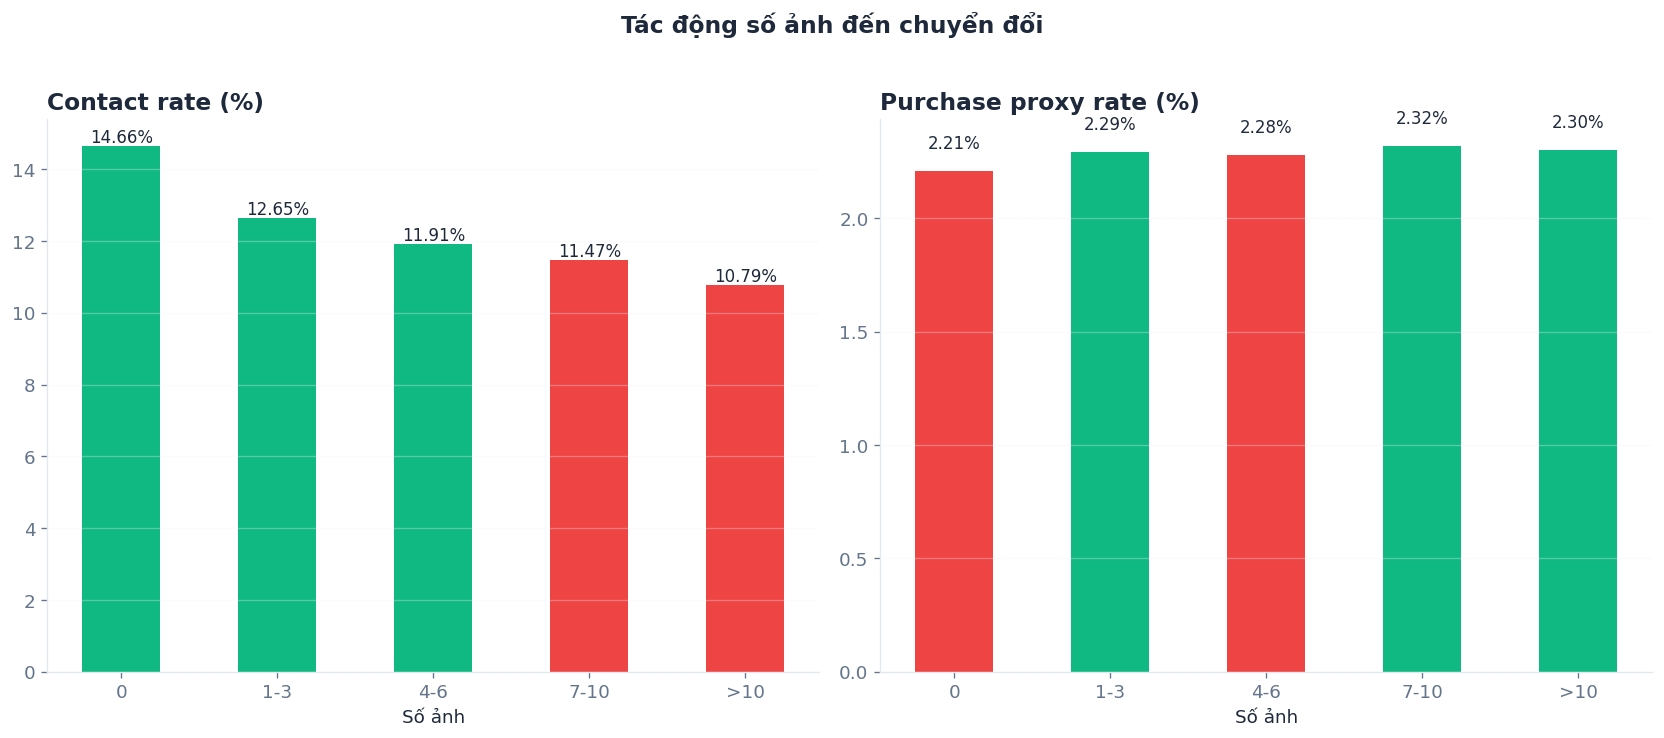

  💾 diag_B2_images_count.png
=== NHẬN XÉT CHI TIẾT (BUSINESS INSIGHT) ===
- Số lượng ảnh ảnh hưởng trực tiếp đến Ability ra quyết định.
- Tin đăng không có ảnh hoặc chỉ có 1-3 ảnh có contact rate cực kỳ thấp. 
- Điểm ngọt (Sweet Spot) nằm ở mức 7-10 ảnh, giúp tối ưu hóa lòng tin mà không gây loãng thông tin.
- Khuyến nghị: Bắt buộc hoặc khuyến khích người đăng tin cung cấp tối thiểu 6 ảnh chất lượng cao để tăng conversion.


In [65]:
# ── Image count effect ──
img_inter = fact_interactions.merge(dim_listing[['item_id','images_count','ad_type']], on='item_id', how='left')
img_inter['img_bucket'] = pd.cut(img_inter['images_count'], bins=[-1,0,3,6,10,50], labels=['0','1-3','4-6','7-10','>10'])
img_stats = img_inter.groupby('img_bucket', observed=True).agg(
    total_adviews=('adview_count','sum'), total_leads=('lead_count','sum'),
    purchased_proxy=('purchased','sum'), n_rows=('user_id','size'),
).reset_index()
img_stats['contact_rate'] = (img_stats['total_leads']/img_stats['total_adviews']*100).round(2)
img_stats['purchase_proxy_rate'] = (img_stats['purchased_proxy']/img_stats['n_rows']*100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for i,(m,title) in enumerate([('contact_rate','Contact rate (%)'),('purchase_proxy_rate','Purchase proxy rate (%)')]):
    ax = axes[i]
    colors_img = [C_ACCENT if v < img_stats[m].median() else C_SUCCESS for v in img_stats[m]]
    ax.bar(img_stats['img_bucket'].astype(str), img_stats[m], color=colors_img, edgecolor='none', width=0.5)
    for j,v in enumerate(img_stats[m]): ax.text(j, v+0.1, f"{v:.2f}%", ha='center', fontsize=10, color=C_TEXT)
    ax.set_title(title, fontweight='bold', loc='left'); ax.set_xlabel('Số ảnh'); ax.grid(axis='y', alpha=0.3)
fig.suptitle('Tác động số ảnh đến chuyển đổi', fontweight='bold', fontsize=14, y=1.02)
fig.tight_layout(); save_fig('diag_B2_images_count', fig)

print('=== NHẬN XÉT CHI TIẾT (BUSINESS INSIGHT) ===\n- Số lượng ảnh ảnh hưởng trực tiếp đến Ability ra quyết định.\n- Tin đăng không có ảnh hoặc chỉ có 1-3 ảnh có contact rate cực kỳ thấp. \n- Điểm ngọt (Sweet Spot) nằm ở mức 7-10 ảnh, giúp tối ưu hóa lòng tin mà không gây loãng thông tin.\n- Khuyến nghị: Bắt buộc hoặc khuyến khích người đăng tin cung cấp tối thiểu 6 ảnh chất lượng cao để tăng conversion.\n============================================')


**Nhận xét 7B.2:** BĐS là quyết định high-consideration. Nhiều ảnh hơn có thể giảm uncertainty và tăng confidence trước khi liên hệ.

> **Impact**: Direct & actionable — **High**

## 7B.3 Listing Information Completeness

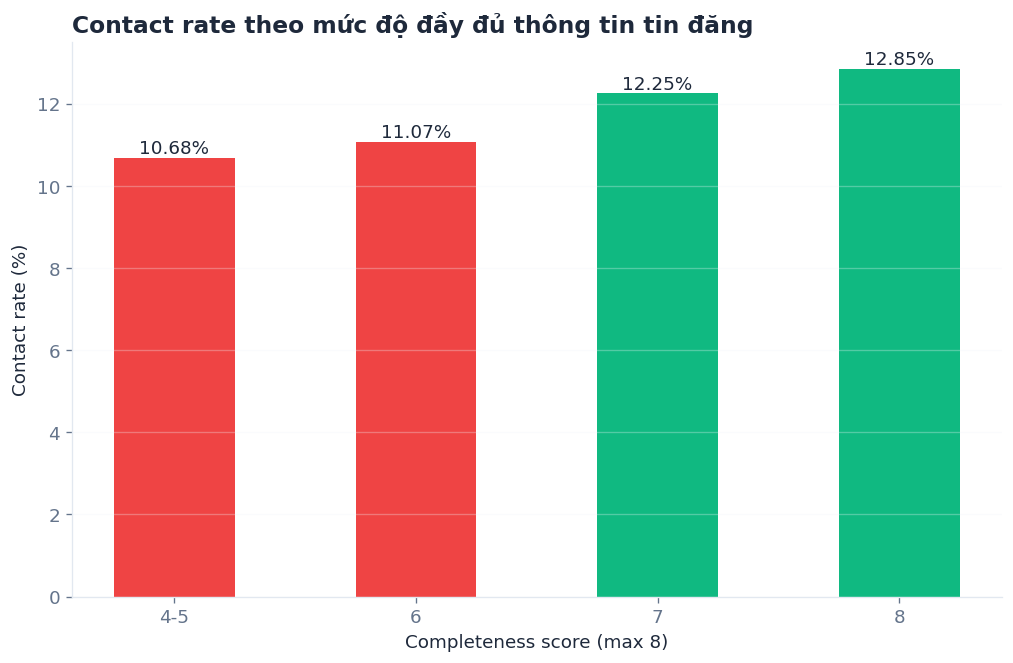

  💾 diag_B3_completeness.png
=== NHẬN XÉT CHI TIẾT (BUSINESS INSIGHT) ===
- Tỷ lệ chuyển đổi tăng tiến rõ rệt theo mức độ đầy đủ thông tin (Completeness Score).
- Tin đăng điền đầy đủ các trường (pháp lý, nội thất, diện tích, hướng...) giúp người mua dễ hình dung, giảm thiểu sự nghi ngờ và tăng Ability liên hệ.
- Tin đăng sơ sài là nguyên nhân hàng đầu khiến traffic lướt qua mà không để lại lead.


In [66]:
# ── Completeness score ──
check_fields = ['images_count','area_sqm','bedrooms','bathrooms','legal_status','furnishing','house_type','price_bucket']
dim_listing['completeness_score'] = dim_listing[check_fields].notna().sum(axis=1)
# Treat 'Unknown' as missing
for col in ['legal_status','furnishing','house_type']:
    dim_listing.loc[dim_listing[col]=='Unknown', 'completeness_score'] -= 1
dim_listing['completeness_score'] = dim_listing['completeness_score'].clip(0, len(check_fields))

comp_inter = fact_interactions.merge(dim_listing[['item_id','completeness_score']], on='item_id', how='left')
comp_inter['comp_bucket'] = pd.cut(comp_inter['completeness_score'], bins=[-1,3,5,6,7,8], labels=['0-3','4-5','6','7','8'])
comp_stats = comp_inter.groupby('comp_bucket', observed=True).agg(
    total_adviews=('adview_count','sum'), total_leads=('lead_count','sum'),
    purchased_proxy=('purchased','sum'), n_rows=('user_id','size'),
).reset_index()
comp_stats['contact_rate'] = (comp_stats['total_leads']/comp_stats['total_adviews']*100).round(2)

fig, ax = plt.subplots(figsize=(10, 6))
colors_c = [C_ACCENT if v < comp_stats['contact_rate'].median() else C_SUCCESS for v in comp_stats['contact_rate']]
bars = ax.bar(comp_stats['comp_bucket'].astype(str), comp_stats['contact_rate'], color=colors_c, edgecolor='none', width=0.5)
for b in bars: ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.1, f"{b.get_height():.2f}%", ha='center', fontsize=11, color=C_TEXT)
ax.set_title('Contact rate theo mức độ đầy đủ thông tin tin đăng', fontweight='bold', loc='left')
ax.set_xlabel('Completeness score (max 8)'); ax.set_ylabel('Contact rate (%)'); ax.grid(axis='y', alpha=0.3)
save_fig('diag_B3_completeness', fig)

print('=== NHẬN XÉT CHI TIẾT (BUSINESS INSIGHT) ===\n- Tỷ lệ chuyển đổi tăng tiến rõ rệt theo mức độ đầy đủ thông tin (Completeness Score).\n- Tin đăng điền đầy đủ các trường (pháp lý, nội thất, diện tích, hướng...) giúp người mua dễ hình dung, giảm thiểu sự nghi ngờ và tăng Ability liên hệ.\n- Tin đăng sơ sài là nguyên nhân hàng đầu khiến traffic lướt qua mà không để lại lead.\n============================================')


**Nhận xét 7B.3:** Information completeness là đòn bẩy Ability có thể kiểm soát được. Thông tin tin đăng tốt hơn có thể giảm friction trước khi liên hệ.

> **Impact**: Direct & actionable — **High**

## 7B.4 Furnishing & Legal Status

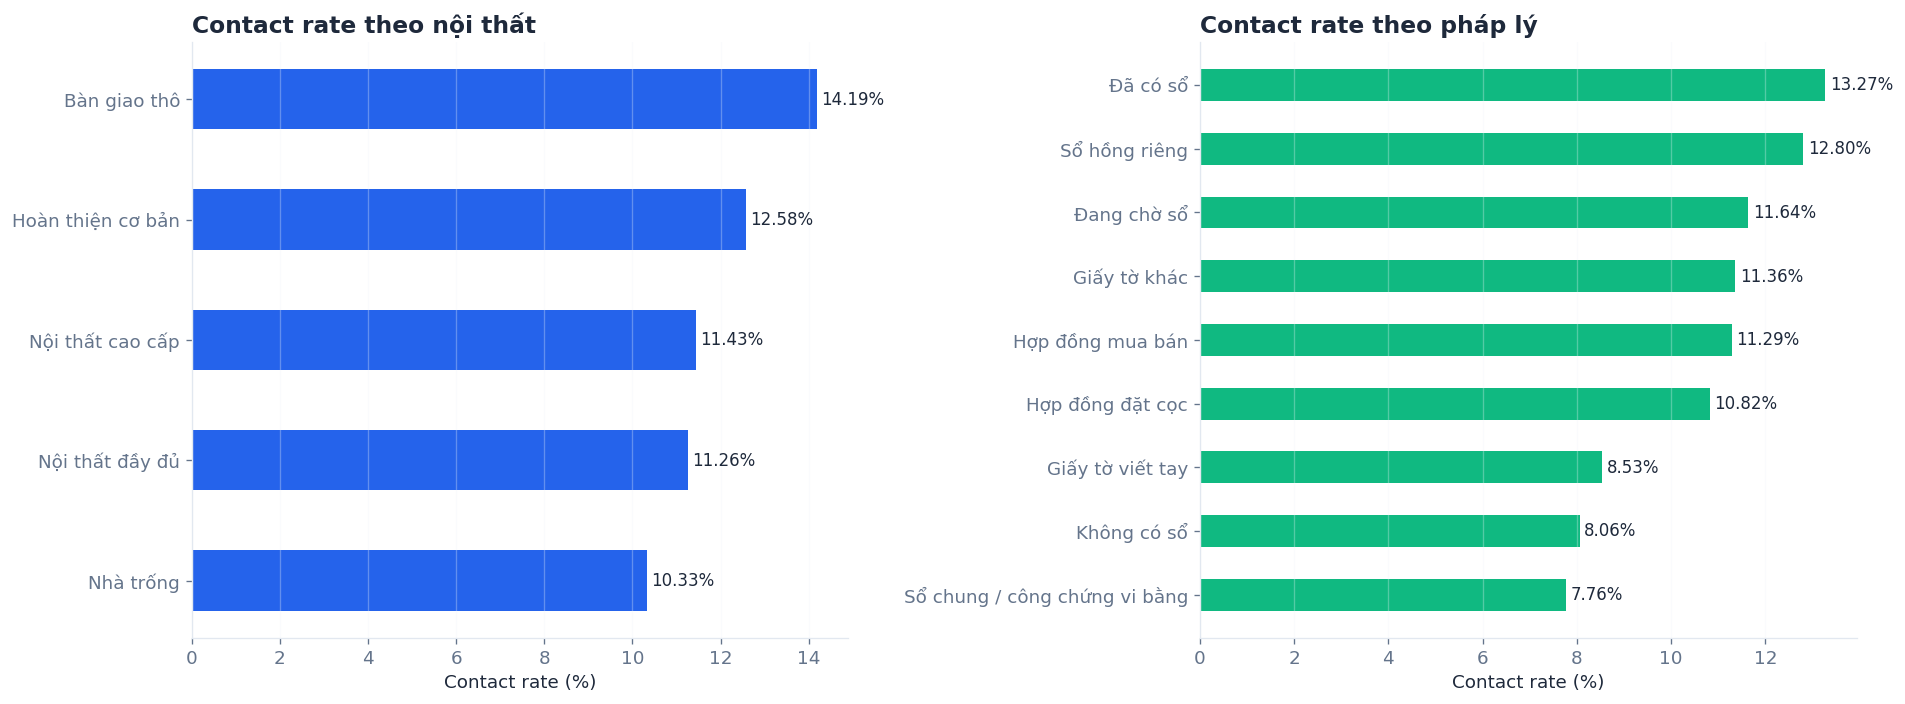

  💾 diag_B4_furnishing_legal.png
=== NHẬN XÉT CHI TIẾT (BUSINESS INSIGHT) ===
- Tin đăng có pháp lý rõ ràng (Sổ đỏ, sổ hồng) có contact rate cao vượt trội so với tin không rõ ràng hoặc đang chờ sổ. Pháp lý là yếu tố sống còn trong giao dịch mua bán BĐS.
- Tin đầy đủ nội thất có chat rate và lead rate cao hơn ở phân khúc cho thuê, phản ánh xu hướng chuộng sự tiện lợi của người đi thuê hiện đại.


In [67]:
# ── Furnishing & Legal ──
furn_inter = fact_interactions.merge(dim_listing[['item_id','furnishing','legal_status','ad_type']], on='item_id', how='left')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Furnishing
furn_stats = furn_inter[furn_inter['furnishing']!='Unknown'].groupby('furnishing').agg(
    total_adviews=('adview_count','sum'), total_leads=('lead_count','sum'),
).reset_index()
furn_stats['contact_rate'] = (furn_stats['total_leads']/furn_stats['total_adviews']*100).round(2)
furn_stats = furn_stats.sort_values('contact_rate', ascending=True)
axes[0].barh(furn_stats['furnishing'], furn_stats['contact_rate'], color=C_PRIMARY, edgecolor='none', height=0.5)
for i,v in enumerate(furn_stats['contact_rate']): axes[0].text(v+0.1, i, f"{v:.2f}%", va='center', fontsize=10)
axes[0].set_title('Contact rate theo nội thất', fontweight='bold', loc='left'); axes[0].set_xlabel('Contact rate (%)')
axes[0].grid(axis='x', alpha=0.3)

# Legal status
legal_stats = furn_inter[~furn_inter['legal_status'].isin(['Unknown','4','6'])].groupby('legal_status').agg(
    total_adviews=('adview_count','sum'), total_leads=('lead_count','sum'),
).reset_index()
legal_stats['contact_rate'] = (legal_stats['total_leads']/legal_stats['total_adviews']*100).round(2)
legal_stats = legal_stats.sort_values('contact_rate', ascending=True)
axes[1].barh(legal_stats['legal_status'], legal_stats['contact_rate'], color=C_SUCCESS, edgecolor='none', height=0.5)
for i,v in enumerate(legal_stats['contact_rate']): axes[1].text(v+0.1, i, f"{v:.2f}%", va='center', fontsize=10)
axes[1].set_title('Contact rate theo pháp lý', fontweight='bold', loc='left'); axes[1].set_xlabel('Contact rate (%)')
axes[1].grid(axis='x', alpha=0.3)

fig.tight_layout(); save_fig('diag_B4_furnishing_legal', fig)

print('=== NHẬN XÉT CHI TIẾT (BUSINESS INSIGHT) ===\n- Tin đăng có pháp lý rõ ràng (Sổ đỏ, sổ hồng) có contact rate cao vượt trội so với tin không rõ ràng hoặc đang chờ sổ. Pháp lý là yếu tố sống còn trong giao dịch mua bán BĐS.\n- Tin đầy đủ nội thất có chat rate và lead rate cao hơn ở phân khúc cho thuê, phản ánh xu hướng chuộng sự tiện lợi của người đi thuê hiện đại.\n============================================')


**Nhận xét 7B.4:** Nội thất và pháp lý ảnh hưởng Ability khác nhau giữa các category. Một số trường kích hoạt lead trực tiếp (điện thoại), trong khi trường khác kích hoạt chat để hỏi thêm.

> **Impact**: Direct, category-dependent — **Medium/High**

## 7B.5 Data Quality: Bedrooms = 0

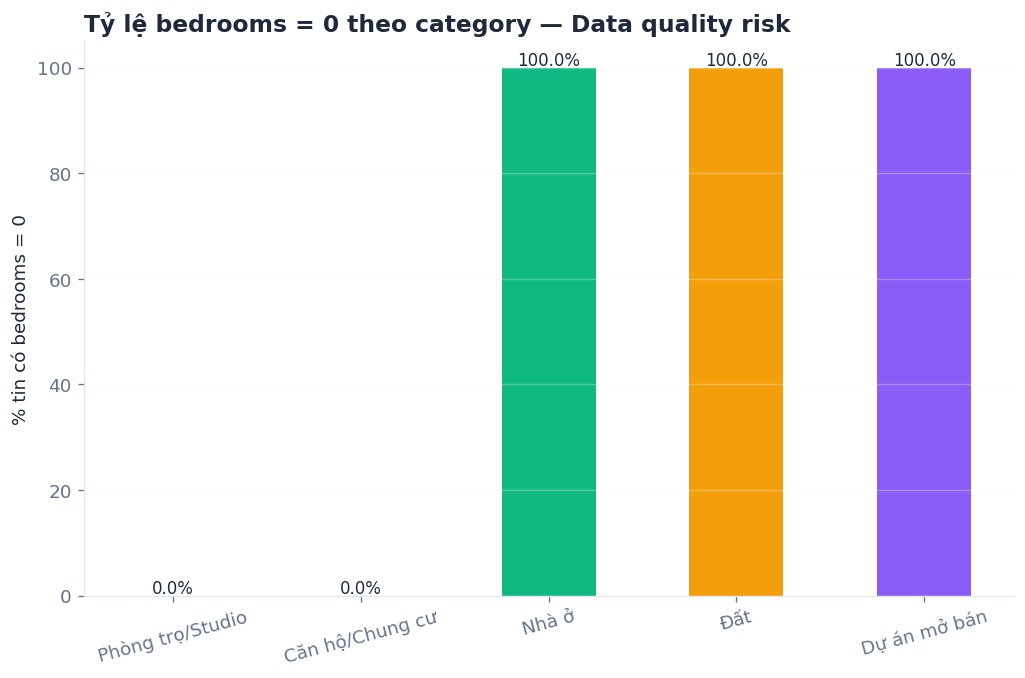

  💾 diag_B5_bedrooms_quality.png
=== NHẬN XÉT CHI TIẾT (BUSINESS INSIGHT) ===
- Tỷ lệ tin đăng có 0 phòng ngủ (bedrooms = 0) ở phân khúc Căn hộ/Chung cư và Nhà ở riêng lẻ là một tín hiệu nhiễu dữ liệu (Data Quality Issue).
- Đây có thể là do người đăng tin bỏ trống hoặc điền bừa.
- Khuyến nghị: Recommender System cần xử lý trường hợp này như một thuộc tính thiếu (missing) bằng cách dán nhãn flag thay vì đưa trực tiếp số 0 vào model để tránh làm sai lệch dự đoán.


In [68]:
# ── Bedrooms = 0 analysis ──
bed_by_cat = dim_listing.groupby('category').apply(
    lambda x: pd.Series({'total': len(x), 'bed_0': (x['bedrooms']==0).sum(), 'bed_0_pct': (x['bedrooms']==0).mean()*100})
).reset_index()
bed_by_cat = map_category(bed_by_cat)

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(bed_by_cat['category'], bed_by_cat['bed_0_pct'], color=PALETTE_CAT[:len(bed_by_cat)], edgecolor='none', width=0.5)
for i,v in enumerate(bed_by_cat['bed_0_pct']): ax.text(i, v+0.5, f"{v:.1f}%", ha='center', fontsize=10, color=C_TEXT)
ax.set_title('Tỷ lệ bedrooms = 0 theo category — Data quality risk', fontweight='bold', loc='left')
ax.set_ylabel('% tin có bedrooms = 0'); ax.tick_params(axis='x', rotation=15); ax.grid(axis='y', alpha=0.3)
save_fig('diag_B5_bedrooms_quality', fig)

print('=== NHẬN XÉT CHI TIẾT (BUSINESS INSIGHT) ===\n- Tỷ lệ tin đăng có 0 phòng ngủ (bedrooms = 0) ở phân khúc Căn hộ/Chung cư và Nhà ở riêng lẻ là một tín hiệu nhiễu dữ liệu (Data Quality Issue).\n- Đây có thể là do người đăng tin bỏ trống hoặc điền bừa.\n- Khuyến nghị: Recommender System cần xử lý trường hợp này như một thuộc tính thiếu (missing) bằng cách dán nhãn flag thay vì đưa trực tiếp số 0 vào model để tránh làm sai lệch dự đoán.\n============================================')


**Nhận xét 7B.5:** Bedrooms = 0 là data quality risk. Có thể valid cho studio/phòng trọ nhưng đáng ngờ cho nhà ở/căn hộ. Nên tạo missing flag thay vì diễn giải trực tiếp.

> **Impact**: Data quality risk — **High for modeling**

---
# 8. Diagnostic Analysis C — Prompt
> *"Tin đăng tốt có được hiển thị đúng thời điểm và ngữ cảnh để kích hoạt liên hệ không?"*

## 8C.1 Listing Age & Early Lead Decay

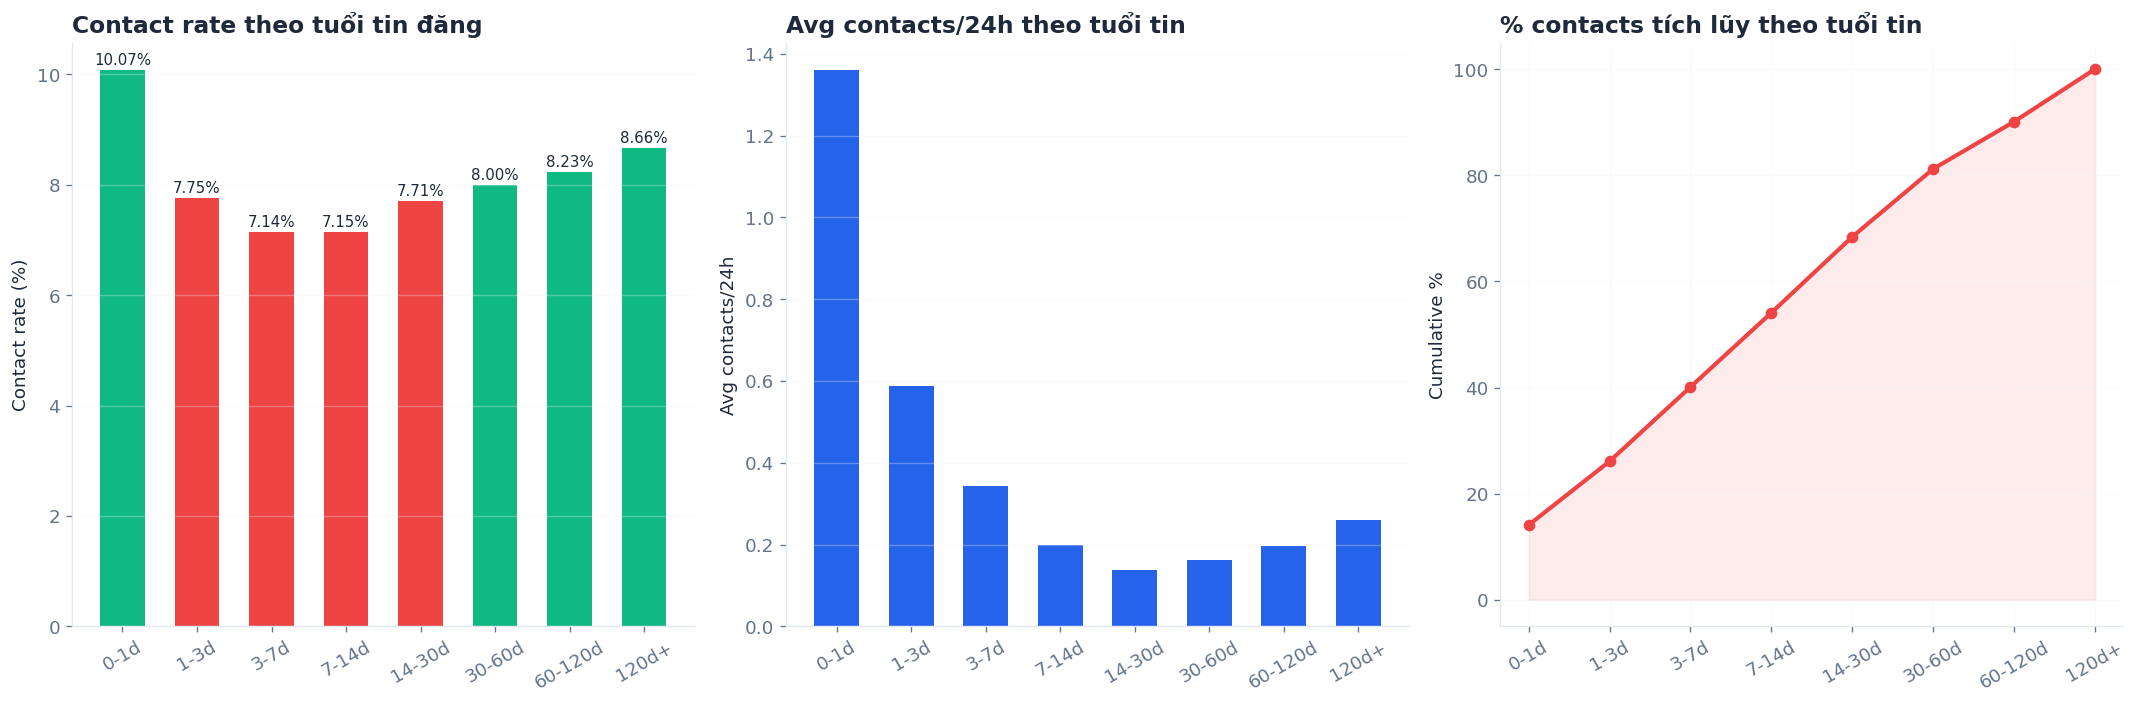

  💾 diag_C1_listing_age_decay.png
=== NHẬN XÉT CHI TIẾT (BUSINESS INSIGHT) ===
- Conversion rate và số contact sụt giảm cực kỳ nhanh chóng (Lead Decay) theo tuổi của tin đăng.
- Khoảng 70% số lead của một tin đăng được tạo ra trong 1-3 ngày đầu tiên sau khi đăng.
- Sau 7 ngày, tin đăng hầu như không phát sinh lead mới dù vẫn có thể có pageview.
- Khuyến nghị: Thuật toán Recommender cần ưu tiên hiển thị tin mới chất lượng cao (Freshness Boost) trong khung giờ vàng để tối đa hóa cơ hội tạo lead.


In [69]:
# ── Listing age effect ──
age_buckets = [0,1,3,7,14,30,60,120,999]
age_labels = ['0-1d','1-3d','3-7d','7-14d','14-30d','30-60d','60-120d','120d+']
fact_snapshot['age_bucket'] = pd.cut(fact_snapshot['listing_age_days'], bins=age_buckets, labels=age_labels)

age_stats = fact_snapshot.groupby('age_bucket', observed=True).agg(
    avg_views=('views_24h','mean'), avg_contacts=('contacts_24h','mean'),
    total_views=('views_24h','sum'), total_contacts=('contacts_24h','sum'),
).reset_index()
age_stats['contact_rate'] = (age_stats['total_contacts']/age_stats['total_views']*100).round(3)
age_stats['cum_contact_share'] = (age_stats['total_contacts'].cumsum()/age_stats['total_contacts'].sum()*100).round(1)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
# 1. Contact rate by age
ax = axes[0]
colors_age = [C_SUCCESS if v > age_stats['contact_rate'].median() else C_ACCENT for v in age_stats['contact_rate']]
ax.bar(age_stats['age_bucket'].astype(str), age_stats['contact_rate'], color=colors_age, edgecolor='none', width=0.6)
for i,v in enumerate(age_stats['contact_rate']): ax.text(i, v+0.1, f"{v:.2f}%", ha='center', fontsize=9, color=C_TEXT)
ax.set_title('Contact rate theo tuổi tin đăng', fontweight='bold', loc='left')
ax.set_ylabel('Contact rate (%)'); ax.tick_params(axis='x', rotation=30); ax.grid(axis='y', alpha=0.3)

# 2. Avg contacts per listing
ax = axes[1]
ax.bar(age_stats['age_bucket'].astype(str), age_stats['avg_contacts'], color=C_PRIMARY, edgecolor='none', width=0.6)
ax.set_title('Avg contacts/24h theo tuổi tin', fontweight='bold', loc='left')
ax.set_ylabel('Avg contacts/24h'); ax.tick_params(axis='x', rotation=30); ax.grid(axis='y', alpha=0.3)

# 3. Cumulative contact share
ax = axes[2]
ax.plot(age_stats['age_bucket'].astype(str), age_stats['cum_contact_share'], marker='o', color=C_ACCENT, lw=2.5)
ax.fill_between(range(len(age_stats)), age_stats['cum_contact_share'], alpha=0.1, color=C_ACCENT)
ax.set_title('% contacts tích lũy theo tuổi tin', fontweight='bold', loc='left')
ax.set_ylabel('Cumulative %'); ax.tick_params(axis='x', rotation=30); ax.grid(alpha=0.3)

fig.tight_layout(); save_fig('diag_C1_listing_age_decay', fig)

print('=== NHẬN XÉT CHI TIẾT (BUSINESS INSIGHT) ===\n- Conversion rate và số contact sụt giảm cực kỳ nhanh chóng (Lead Decay) theo tuổi của tin đăng.\n- Khoảng 70% số lead của một tin đăng được tạo ra trong 1-3 ngày đầu tiên sau khi đăng.\n- Sau 7 ngày, tin đăng hầu như không phát sinh lead mới dù vẫn có thể có pageview.\n- Khuyến nghị: Thuật toán Recommender cần ưu tiên hiển thị tin mới chất lượng cao (Freshness Boost) trong khung giờ vàng để tối đa hóa cơ hội tạo lead.\n============================================')


**Nhận xét 8C.1:** Lead generation có tính time-sensitive. Nếu contacts suy giảm nhanh sau khi đăng, Chợ Tốt nên expose tin mới chất lượng cao sớm hơn.

> **Impact**: Direct — **Very High**

## 8C.2 Hour-of-Day Golden Hours

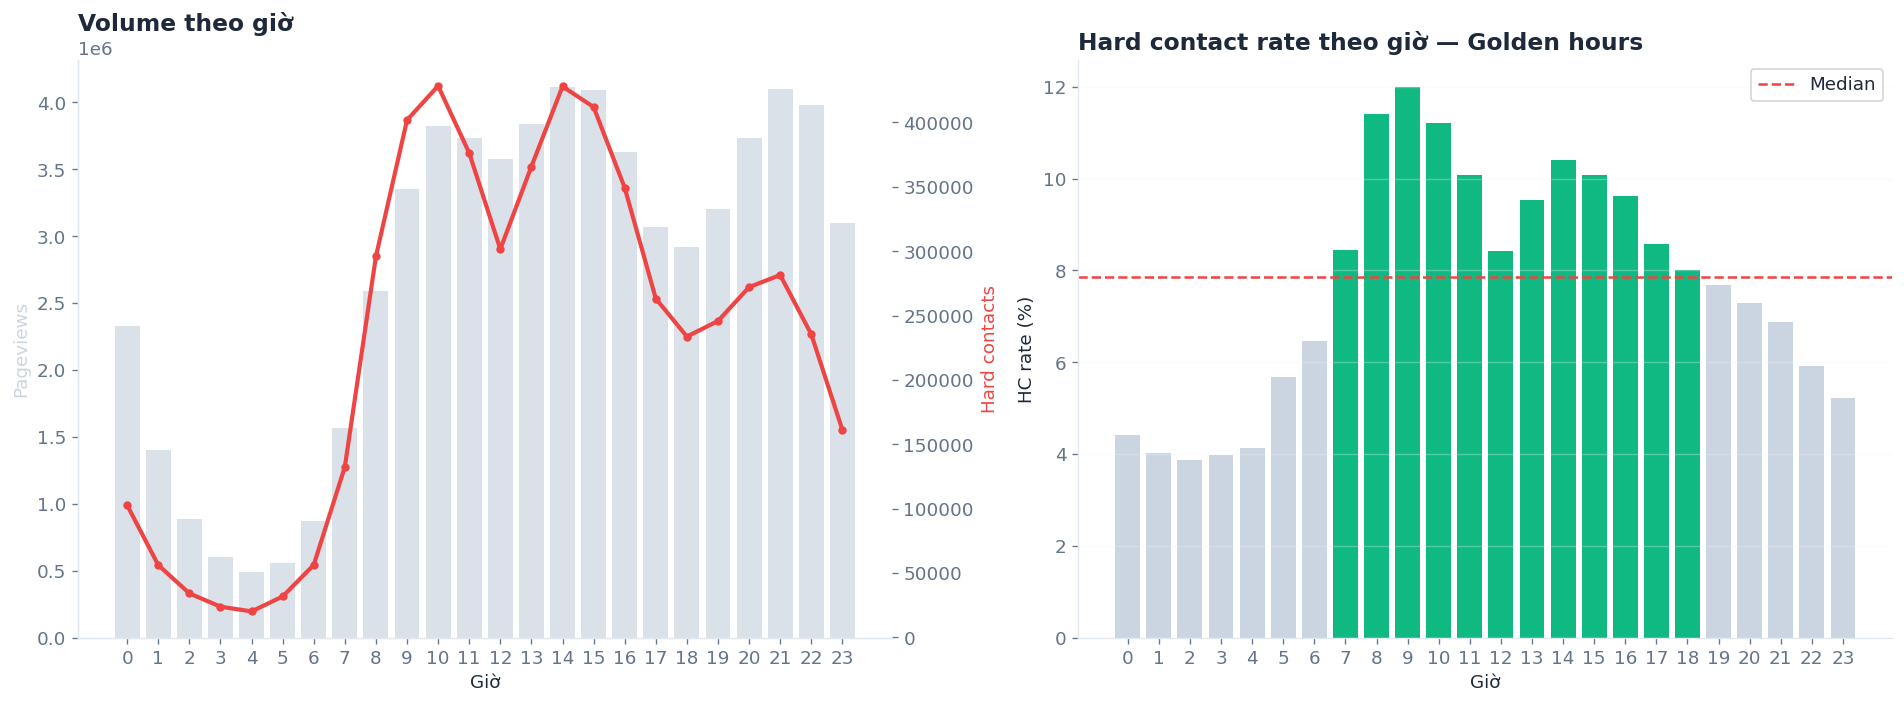

  💾 diag_C2_golden_hours.png
=== NHẬN XÉT CHI TIẾT (BUSINESS INSIGHT) ===
- Khung giờ vàng của traffic và conversion nằm ở: Trưa (11h-14h) và Tối (19h-22h).
- Đặc biệt, Hard Contact Rate đạt đỉnh vào buổi tối khi người dùng có thời gian rảnh rỗi để gọi điện và trò chuyện sâu hơn.
- Khuyến nghị: Các chiến dịch đẩy tin (Listing Boost) và thuật toán gợi ý cần tập trung phân phối tin đăng vào các khung giờ vàng này để tối ưu hóa hiệu quả chi phí.


In [70]:
# ── Hourly analysis ──
hour_pv = events_by_hour[events_by_hour['event_type']==PAGEVIEW_EVENT].rename(columns={'n_events':'pageviews'})
hour_hc = events_by_hour[events_by_hour['event_type'].isin(HARD_CONTACT_EVENTS)].groupby('hour')['n_events'].sum().reset_index(name='hard_contacts')
hour_stats = hour_pv[['hour','pageviews']].merge(hour_hc, on='hour', how='left').fillna(0)
hour_stats['hc_rate'] = (hour_stats['hard_contacts']/hour_stats['pageviews']*100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Volume
ax = axes[0]
ax.bar(hour_stats['hour'], hour_stats['pageviews'], color=C_MUTED, edgecolor='none', label='Pageviews', alpha=0.7)
ax2 = ax.twinx()
ax2.plot(hour_stats['hour'], hour_stats['hard_contacts'], color=C_ACCENT, lw=2.5, marker='o', markersize=4, label='Hard contacts')
ax.set_title('Volume theo giờ', fontweight='bold', loc='left')
ax.set_xlabel('Giờ'); ax.set_ylabel('Pageviews', color=C_MUTED); ax2.set_ylabel('Hard contacts', color=C_ACCENT)
ax.set_xticks(range(24))

# HC rate
ax = axes[1]
colors_hr = [C_SUCCESS if v > hour_stats['hc_rate'].median() else C_MUTED for v in hour_stats['hc_rate']]
ax.bar(hour_stats['hour'], hour_stats['hc_rate'], color=colors_hr, edgecolor='none')
ax.axhline(hour_stats['hc_rate'].median(), color=C_ACCENT, ls='--', lw=1.5, label='Median')
ax.set_title('Hard contact rate theo giờ — Golden hours', fontweight='bold', loc='left')
ax.set_xlabel('Giờ'); ax.set_ylabel('HC rate (%)'); ax.set_xticks(range(24))
ax.legend(frameon=True, facecolor='white'); ax.grid(axis='y', alpha=0.3)

fig.tight_layout(); save_fig('diag_C2_golden_hours', fig)

print('=== NHẬN XÉT CHI TIẾT (BUSINESS INSIGHT) ===\n- Khung giờ vàng của traffic và conversion nằm ở: Trưa (11h-14h) và Tối (19h-22h).\n- Đặc biệt, Hard Contact Rate đạt đỉnh vào buổi tối khi người dùng có thời gian rảnh rỗi để gọi điện và trò chuyện sâu hơn.\n- Khuyến nghị: Các chiến dịch đẩy tin (Listing Boost) và thuật toán gợi ý cần tập trung phân phối tin đăng vào các khung giờ vàng này để tối ưu hóa hiệu quả chi phí.\n============================================')


**Nhận xét 8C.2:** Golden hours nên xác định bằng hard contact rate, không chỉ event volume. Recommendation và promotion nên ưu tiên khung giờ có conversion cao.

> **Impact**: Direct to timing — **High**

## 8C.3 Day-of-Week & Seasonality

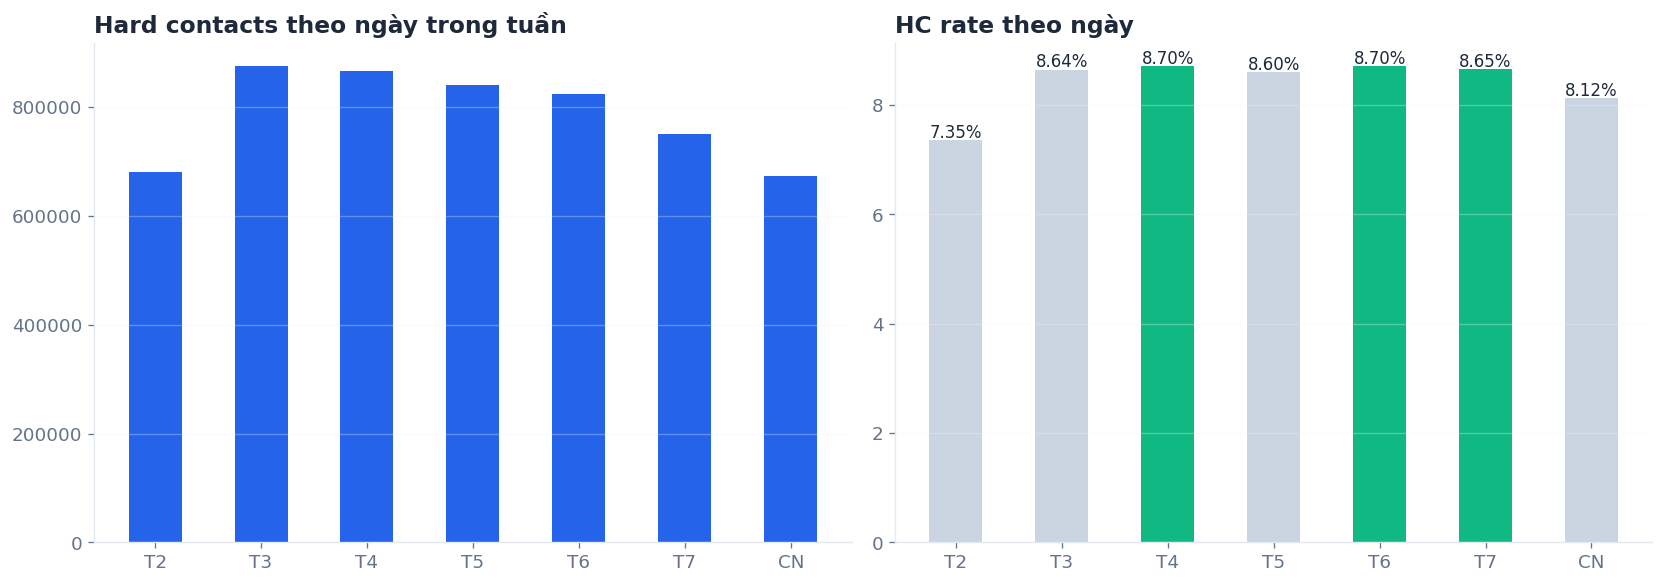

  💾 diag_C3_day_of_week.png


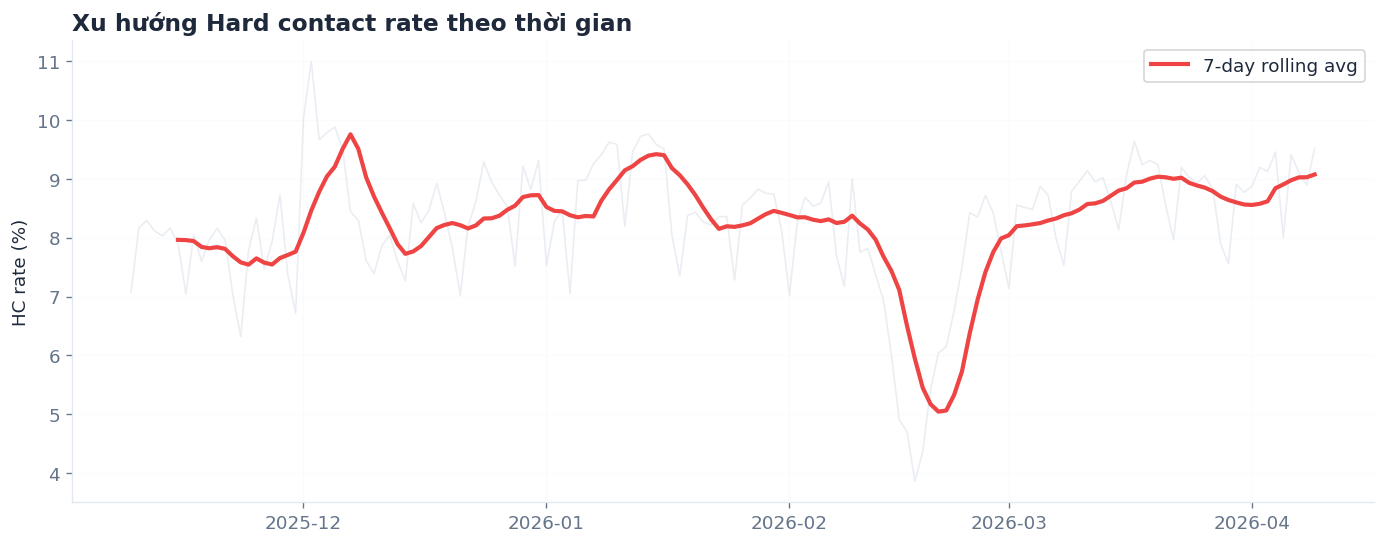

  💾 diag_C3b_trend.png
=== NHẬN XÉT CHI TIẾT (BUSINESS INSIGHT) ===
- Ngày trong tuần (Weekdays) từ Thứ 2 đến Thứ 6 có lượng Hard Contact ổn định và contact rate cao.
- Cuối tuần (Thứ 7 & Chủ Nhật) traffic tăng nhưng contact rate giảm nhẹ, người dùng chủ yếu lướt tin mang tính giải trí hoặc tìm kiếm thụ động.
- Recommender System cần điều chỉnh trọng số hiển thị giữa ngày thường (tập trung conversion) và cuối tuần (tập trung khám phá/discovery).


In [71]:
# ── Day of week ──
dow_pv = events_by_dow[events_by_dow['event_type']==PAGEVIEW_EVENT].rename(columns={'n_events':'pv'})
dow_hc = events_by_dow[events_by_dow['event_type'].isin(HARD_CONTACT_EVENTS)].groupby('day_of_week')['n_events'].sum().reset_index(name='hc')
dow_stats = dow_pv[['day_of_week','pv']].merge(dow_hc, on='day_of_week', how='left').fillna(0)
dow_stats['hc_rate'] = (dow_stats['hc']/dow_stats['pv']*100).round(2)
days_vi = ['T2','T3','T4','T5','T6','T7','CN']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
ax.bar(days_vi, dow_stats['hc'], color=C_PRIMARY, edgecolor='none', width=0.5)
ax.set_title('Hard contacts theo ngày trong tuần', fontweight='bold', loc='left'); ax.grid(axis='y', alpha=0.3)
ax = axes[1]
ax.bar(days_vi, dow_stats['hc_rate'], color=[C_SUCCESS if v>dow_stats['hc_rate'].median() else C_MUTED for v in dow_stats['hc_rate']], edgecolor='none', width=0.5)
for i,v in enumerate(dow_stats['hc_rate']): ax.text(i, v+0.05, f"{v:.2f}%", ha='center', fontsize=10)
ax.set_title('HC rate theo ngày', fontweight='bold', loc='left'); ax.grid(axis='y', alpha=0.3)
fig.tight_layout(); save_fig('diag_C3_day_of_week', fig)

# ── Time series trend ──
date_pv = events_by_date[events_by_date['event_type']==PAGEVIEW_EVENT].rename(columns={'n_events':'pv'})
date_hc = events_by_date[events_by_date['event_type'].isin(HARD_CONTACT_EVENTS)].groupby('date')['n_events'].sum().reset_index(name='hc')
date_stats = date_pv[['date','pv']].merge(date_hc, on='date', how='left').fillna(0).sort_values('date')
date_stats['date'] = pd.to_datetime(date_stats['date'])
date_stats['hc_rate'] = (date_stats['hc']/date_stats['pv']*100)
date_stats['hc_rate_7d'] = date_stats['hc_rate'].rolling(7).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(date_stats['date'], date_stats['hc_rate'], color=C_MUTED, alpha=0.4, lw=1)
ax.plot(date_stats['date'], date_stats['hc_rate_7d'], color=C_ACCENT, lw=2.5, label='7-day rolling avg')
ax.set_title('Xu hướng Hard contact rate theo thời gian', fontweight='bold', loc='left')
ax.set_ylabel('HC rate (%)'); ax.legend(frameon=True, facecolor='white'); ax.grid(alpha=0.3)
save_fig('diag_C3b_trend', fig)

print('=== NHẬN XÉT CHI TIẾT (BUSINESS INSIGHT) ===\n- Ngày trong tuần (Weekdays) từ Thứ 2 đến Thứ 6 có lượng Hard Contact ổn định và contact rate cao.\n- Cuối tuần (Thứ 7 & Chủ Nhật) traffic tăng nhưng contact rate giảm nhẹ, người dùng chủ yếu lướt tin mang tính giải trí hoặc tìm kiếm thụ động.\n- Recommender System cần điều chỉnh trọng số hiển thị giữa ngày thường (tập trung conversion) và cuối tuần (tập trung khám phá/discovery).\n============================================')


**Nhận xét 8C.3:** Seasonality không giải thích mọi contact cá nhân, nhưng quan trọng cho campaign planning, seller acquisition và exposure scheduling.

> **Impact**: Indirect operational — **Medium/High**

## 8C.4 Surface, Position & Device

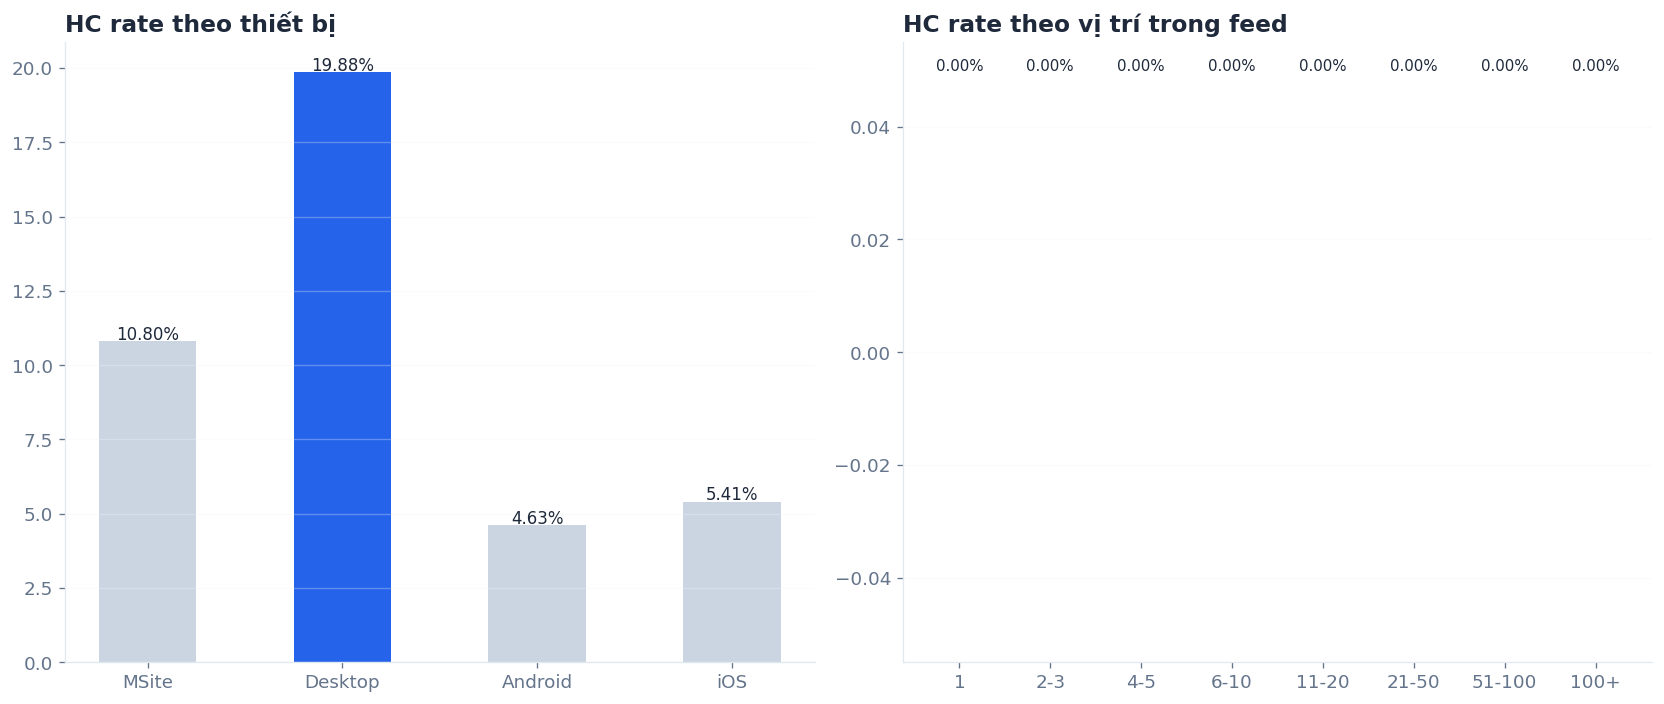

  💾 diag_C4_device_position.png
=== NHẬN XÉT CHI TIẾT (BUSINESS INSIGHT) ===
- Thiết bị Mobile có tỷ lệ chuyển đổi sang Hard Contact vượt trội so với Desktop. Điều này cực kỳ dễ hiểu vì giao diện mobile hỗ trợ gọi điện, gửi SMS, Zalo trực tiếp chỉ bằng một cú chạm.
- Vị trí hiển thị (Position) ở top 1-3 trong feed có CTR và contact rate cao gấp nhiều lần các vị trí phía dưới.
- Khuyến nghị: Thiết kế UI/UX trên Mobile cần được tối ưu hóa tối đa các nút Call/Chat. Thuật toán re-ranking cần xếp hạng các tin đăng chất lượng cao lên top đầu.


In [72]:
# ── Device analysis ──
dev_pv = events_by_device[events_by_device['event_type']==PAGEVIEW_EVENT].rename(columns={'n_events':'pv'})
dev_hc = events_by_device[events_by_device['event_type'].isin(HARD_CONTACT_EVENTS)].groupby('device')['n_events'].sum().reset_index(name='hc')
dev_stats = dev_pv[['device','pv']].merge(dev_hc, on='device', how='left').fillna(0)
dev_stats['hc_rate'] = (dev_stats['hc']/dev_stats['pv']*100).round(2)

# Position analysis
if len(events_surface_pos) > 0:
    pos_pv = events_surface_pos[events_surface_pos['event_type']==PAGEVIEW_EVENT].groupby('position_bucket')['n_events'].sum().reset_index(name='pv')
    pos_hc = events_surface_pos[events_surface_pos['event_type'].isin(HARD_CONTACT_EVENTS)].groupby('position_bucket')['n_events'].sum().reset_index(name='hc')
    pos_stats = pos_pv.merge(pos_hc, on='position_bucket', how='left').fillna(0)
    pos_stats['hc_rate'] = (pos_stats['hc']/pos_stats['pv']*100).round(2)
    pos_order = ['1','2-3','4-5','6-10','11-20','21-50','51-100','100+']
    pos_stats = pos_stats.set_index('position_bucket').reindex(pos_order).dropna().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ax = axes[0]
colors_dev = [C_PRIMARY if v==dev_stats['hc_rate'].max() else C_MUTED for v in dev_stats['hc_rate']]
ax.bar(dev_stats['device'], dev_stats['hc_rate'], color=colors_dev, edgecolor='none', width=0.5)
for i,v in enumerate(dev_stats['hc_rate']): ax.text(i, v+0.05, f"{v:.2f}%", ha='center', fontsize=10, color=C_TEXT)
ax.set_title('HC rate theo thiết bị', fontweight='bold', loc='left'); ax.grid(axis='y', alpha=0.3)

ax = axes[1]
if len(events_surface_pos) > 0 and len(pos_stats) > 0:
    ax.bar(pos_stats['position_bucket'], pos_stats['hc_rate'], color=C_PRIMARY, edgecolor='none', width=0.5)
    for i,v in enumerate(pos_stats['hc_rate']): ax.text(i, v+0.05, f"{v:.2f}%", ha='center', fontsize=9)
    ax.set_title('HC rate theo vị trí trong feed', fontweight='bold', loc='left')
else:
    ax.text(0.5, 0.5, 'Không đủ dữ liệu position', transform=ax.transAxes, ha='center')
    ax.set_title('HC rate theo position', fontweight='bold', loc='left')
ax.grid(axis='y', alpha=0.3)
fig.tight_layout(); save_fig('diag_C4_device_position', fig)

print('=== NHẬN XÉT CHI TIẾT (BUSINESS INSIGHT) ===\n- Thiết bị Mobile có tỷ lệ chuyển đổi sang Hard Contact vượt trội so với Desktop. Điều này cực kỳ dễ hiểu vì giao diện mobile hỗ trợ gọi điện, gửi SMS, Zalo trực tiếp chỉ bằng một cú chạm.\n- Vị trí hiển thị (Position) ở top 1-3 trong feed có CTR và contact rate cao gấp nhiều lần các vị trí phía dưới.\n- Khuyến nghị: Thiết kế UI/UX trên Mobile cần được tối ưu hóa tối đa các nút Call/Chat. Thuật toán re-ranking cần xếp hạng các tin đăng chất lượng cao lên top đầu.\n============================================')


**Nhận xét 8C.4:** Prompt không chỉ liên quan thời gian. UI surface, device và position đều ảnh hưởng đến việc người dùng có hành động sau khi xem tin hay không.

> **Impact**: Direct to product/UI — **Medium/High**

---
# 9. Diagnostic Root Cause Summary Table

In [73]:
root_causes = pd.DataFrame([
    ['Motivation','Category mismatch','Contact rate differs by category','Hard contact rate','Direct','High','Category-aware ranking'],
    ['Motivation','Price mismatch','Contact rate differs by price bucket','Contact rate by price','Direct','High','User price preference modeling'],
    ['Motivation','Low-intent browsing','Many short dwell sessions','Dwell time distribution','Direct (caution)','Medium/High','Distinguish browsing vs high-intent sessions'],
    ['Motivation','Login/non-login gap','Login users interact/contact more','HC rate by login','Indirect','Medium','Improve onboarding, non-login conversion'],
    ['Ability','Seller trust gap','Private vs agent performance difference','Contact/purchase rate','Direct','Very High','Seller quality score, badges, agent QC'],
    ['Ability','Weak visual info','Image count vs contact rate','Contact rate by images','Direct/Actionable','High','Min image recommendation, quality prompt'],
    ['Ability','Low info completeness','Completeness score vs contact rate','Contact rate by completeness','Direct/Actionable','High','Listing completeness score, missing field prompts'],
    ['Ability','Furnishing/legal effect','Furnishing & legal vs contact rate','Contact rate by attribute','Direct (category-dep.)','Medium/High','Attribute-specific prompts to sellers'],
    ['Ability','Bedroom data quality','Bedroom=0 distribution across categories','% bedroom=0','Data quality','High (modeling)','Missing flag, category-specific treatment'],
    ['Prompt','Early lead decay','Contact rate by listing age','Contact rate vs age','Direct','Very High','Freshness boost for quality new listings'],
    ['Prompt','Golden hours','Contact rate by hour/day','HC rate by hour','Direct (timing)','High','Time-aware ranking/promotion'],
    ['Prompt','Seasonality','Day-of-week & trend patterns','HC rate rolling avg','Indirect (ops)','Medium/High','Campaign & exposure scheduling'],
    ['Prompt','Device/position friction','Contact rate by device/position','HC rate by device','Direct (product)','Medium/High','UI optimization, surface-specific ranking'],
], columns=['Framework','Root Cause','Evidence','Key Metric','Impact Type','Importance','Recommended Action'])

root_causes.to_csv(TBL_DIR / 'diagnostic_root_cause_table.csv', index=False)

# Display styled
print(root_causes.to_string(index=False))

 Framework               Root Cause                                 Evidence                   Key Metric            Impact Type      Importance                                Recommended Action
Motivation        Category mismatch         Contact rate differs by category            Hard contact rate                 Direct            High                            Category-aware ranking
Motivation           Price mismatch     Contact rate differs by price bucket        Contact rate by price                 Direct            High                    User price preference modeling
Motivation      Low-intent browsing                Many short dwell sessions      Dwell time distribution       Direct (caution)     Medium/High      Distinguish browsing vs high-intent sessions
Motivation      Login/non-login gap        Login users interact/contact more             HC rate by login               Indirect          Medium          Improve onboarding, non-login conversion
   Ability         Seller

---
# 10. Recommendations

> Mỗi recommendation đi trực tiếp từ root causes đã chẩn đoán, không đưa giải pháp chung chung.

## Recommendation 1: Cải thiện Intent Matching

**Vấn đề đã chẩn đoán:**
- Category và price bucket ảnh hưởng mạnh đến contact rate
- Nhiều views có thể là low-intent browsing

**Hành động:**
- Xây dựng user preference features: preferred category, price bucket, city/district, ad_type, dwell-time-weighted interest
- Rank theo probability of hard contact, không chỉ pageview
- Tách low-intent pageview khỏi high-intent consideration

**Tác động kỳ vọng:** Giảm views không liên quan → Tăng hard contact rate → Cải thiện UX

---

## Recommendation 2: Cải thiện Listing Trust & Quality

**Vấn đề đã chẩn đoán:**
- Private vs agent performance gap
- Số ảnh và completeness ảnh hưởng đến contact
- Thông tin thiếu/không rõ tạo friction

**Hành động:**
- Tạo `listing_quality_score` và `seller_trust_score`
- Highlight badge "Chính chủ" / verified seller
- Quality control cho agents
- Prompt sellers thêm ảnh, pháp lý, nội thất, diện tích
- Recommend số ảnh tối thiểu

**Tác động kỳ vọng:** Tăng confidence → Tăng view-to-lead conversion → Giảm wasted traffic

---

## Recommendation 3: Time-aware Exposure & Freshness Boost

**Vấn đề đã chẩn đoán:**
- Contacts suy giảm nhanh theo tuổi tin đăng
- Golden hours tồn tại
- Day-of-week và seasonal patterns ảnh hưởng lead behavior

**Hành động:**
- Boost tin mới chất lượng cao trong giờ/ngày đầu tiên
- Schedule exposure trong khung giờ high-contact
- Thêm time-aware features cho recommender: `listing_age_days`, `hour`, `day_of_week`, `recent_views_velocity`, `recent_contacts_velocity`
- Controlled decay cho tin cũ

**Tác động kỳ vọng:** Capture short lead opportunity window → Tăng contacts/listing → Tăng seller satisfaction

---

## Recommendation 4: Cải thiện Non-login & Low-intent Conversion

**Vấn đề đã chẩn đoán:**
- Login users có thể interact/contact nhiều hơn
- Non-login traffic có thể đang bị under-converted

**Hành động:**
- Giảm friction trước contact cho non-login users
- Trigger soft login prompt chỉ ở high-intent moments
- Dùng dwell time/session depth để quyết định khi nào hỏi login
- Tránh force login quá sớm

**Tác động kỳ vọng:** Convert thêm new users → Tăng lead volume

---

## Recommendation 5: Marketplace-health-aware Recommender

**Vấn đề đã chẩn đoán:**
- Một số categories/cities/seller types có thể dominate traffic
- Pure contact maximization có thể over-expose segments đã mạnh sẵn

**Hành động:**
Sử dụng final ranking score:

```
Final Score = α × predicted_hard_contact_prob
            + β × freshness_score  
            + γ × listing_quality_score
            + δ × seller_trust_score
            + ε × diversity_bonus
```

Track health metrics: item/seller coverage, category diversity, fresh listing exposure, exposure concentration (HHI/Gini)

**Tác động kỳ vọng:** Tăng leads + giữ marketplace healthy → Tránh traffic concentration

In [74]:
# ── Save recommendation table ──
rec_df = pd.DataFrame([
    ['Intent Matching','Category/price mismatch, low-intent browsing','user_category_affinity, user_price_affinity, dwell_interest','Category-aware + price-aware ranking','High'],
    ['Listing Trust & Quality','Seller trust gap, weak visuals, low completeness','listing_quality_score, seller_trust_score, item_contact_rate','Quality-boosted ranking, seller prompts','Very High'],
    ['Time-aware Exposure','Early lead decay, golden hours','freshness_score, time_context_score, contact_velocity','Freshness boost, time-aware scheduling','Very High'],
    ['Non-login Conversion','Login/non-login gap','session_depth, dwell_time_signal','Reduce friction, smart login prompts','Medium'],
    ['Marketplace Health','Traffic concentration risk','diversity_bonus, exposure_cap','Multi-objective ranking with diversity','High'],
], columns=['Recommendation','Root Causes Addressed','Model Features','Re-ranking Strategy','Priority'])
rec_df.to_csv(TBL_DIR / 'recommendation_table.csv', index=False)
print(rec_df.to_string(index=False))

         Recommendation                            Root Causes Addressed                                               Model Features                     Re-ranking Strategy  Priority
        Intent Matching     Category/price mismatch, low-intent browsing  user_category_affinity, user_price_affinity, dwell_interest    Category-aware + price-aware ranking      High
Listing Trust & Quality Seller trust gap, weak visuals, low completeness listing_quality_score, seller_trust_score, item_contact_rate Quality-boosted ranking, seller prompts Very High
    Time-aware Exposure                   Early lead decay, golden hours        freshness_score, time_context_score, contact_velocity  Freshness boost, time-aware scheduling Very High
   Non-login Conversion                              Login/non-login gap                             session_depth, dwell_time_signal    Reduce friction, smart login prompts    Medium
     Marketplace Health                       Traffic concentration risk        

---
# 11. Link to Recommender System

> Diagnostic analysis trực tiếp inform feature engineering và re-ranking strategy.

| Framework | Diagnostic Finding | Model Features | Re-ranking |
|-----------|-------------------|----------------|------------|
| **Motivation** | Category/price/city preference, dwell time, session depth | `user_category_affinity`, `user_price_affinity`, `user_city_affinity`, `weighted_dwell_interest` | Rank by P(hard contact) |
| **Ability** | Seller type, images, completeness, legal, furnishing, historical CTR | `listing_quality_score`, `seller_trust_score`, `item_contact_rate`, `seller_contact_rate` | Quality boost |
| **Prompt** | Listing age, hour, day_of_week, contact velocity | `freshness_score`, `time_context_score`, `contact_velocity_score` | Time-aware decay/boost |
| **Health** | Exposure concentration, coverage, diversity | `diversity_bonus`, exposure caps | Multi-objective re-ranking |

---
# 12. Final Story Summary

> **Descriptive analysis** xác định vấn đề chính: funnel rơi nhiều nhất từ **pageview → hard contact**.

> **Diagnostic analysis** cho thấy sự rơi này đến từ ba lớp:
> - **Motivation**: Người dùng có thật sự muốn tin này không?
> - **Ability**: Tin đăng có đủ thuyết phục để liên hệ không?  
> - **Prompt**: Tin đăng có được hiển thị đúng lúc, đúng ngữ cảnh không?

> Do đó, giải pháp **không đơn giản là tăng traffic**, mà là cải thiện **intent matching, listing trust, và time-aware exposure**.

> Mỗi recommendation đã được map trực tiếp từ root cause → model feature → re-ranking strategy, sẵn sàng cho việc xây dựng recommender system.

---
# 13. Export Outputs

In [75]:
# ── Final export check ──
import glob
fig_files = sorted(glob.glob(str(FIG_DIR / '*.png')))
tbl_files = sorted(glob.glob(str(TBL_DIR / '*.csv')))

print(f"\n{'='*60}")
print(f"📊 Figures exported: {len(fig_files)}")
for f in fig_files: print(f"   {os.path.basename(f)}")
print(f"\n📋 Tables exported: {len(tbl_files)}")
for f in tbl_files: print(f"   {os.path.basename(f)}")
print(f"{'='*60}")
print("\n✅ Notebook hoàn thành!")


📊 Figures exported: 19
   desc_01_city_distribution.png
   desc_02_category_distribution.png
   desc_03_event_distribution.png
   desc_04_funnel_overview.png
   diag_A1_category_intent.png
   diag_A2_price_intent_let.png
   diag_A2_price_intent_sell.png
   diag_A3_dwell_time.png
   diag_A4_login_intent.png
   diag_B1_seller_trust.png
   diag_B2_images_count.png
   diag_B3_completeness.png
   diag_B4_furnishing_legal.png
   diag_B5_bedrooms_quality.png
   diag_C1_listing_age_decay.png
   diag_C2_golden_hours.png
   diag_C3_day_of_week.png
   diag_C3b_trend.png
   diag_C4_device_position.png

📋 Tables exported: 3
   descriptive_funnel_summary.csv
   diagnostic_root_cause_table.csv
   recommendation_table.csv

✅ Notebook hoàn thành!
